<a href="https://colab.research.google.com/github/mustafaberberler/fraud-detection/blob/main/train_lightgbm2222.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LightGBM Hybrid Training — Sparkov Credit Card Fraud Dataset

**Amaç:** AE anomaly score + davranışsal/bağlamsal feature'ları birleştirerek denetimli fraud sınıflandırma.  
**Pipeline:** Autoencoder (1. kademe, denetimsiz) → LightGBM (2. kademe, denetimli, re-ranking)  
**Girdi:** `train_2019_with_ae_scores.csv` (AE notebook çıktısı)  
**Çıktı:** `lgbm_model.pkl`, `lgbm_feature_contract.json`, `training_report.json`

**Deney Tasarımı (Ablation):**
1. LightGBM-Only (AE score olmadan)
2. AE + LightGBM Hybrid (ae_anomaly_score dahil) ← hedef

Bu karşılaştırma tezde hibrit yaklaşımın katkısını kanıtlamak için kritik.

## 0) Environment Setup

In [ ]:
!pip install lightgbm optuna shap optuna-integration --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ---- Paths ----
TRAIN_PATH = "/content/drive/MyDrive/thesis/models/train_2019_with_ae_scores.csv"
VALID_PATH = "/content/drive/MyDrive/thesis/models/valid_2020_with_ae_scores.csv"
TEST_PATH  = "/content/drive/MyDrive/thesis/models/test_final_2020_with_ae_scores.csv"

MODEL_SAVE_DIR = "/content/drive/MyDrive/thesis/models"

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
from optuna_integration import LightGBMPruningCallback

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    average_precision_score
)

np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1) Feature Contract

LightGBM, AE'den farklı olarak **hem sayısal hem kategorik** feature kullanır.  
Ayrıca `ae_anomaly_score` hybrid bileşen olarak eklenir.

**Leakage kontrolü:** `is_fraud` hedef değişken, feature olarak asla kullanılmaz.  
Risk score'ları (merchant_fraud_rate vb.) varsa dahil etmiyoruz — bunlar label leakage yaratır.

In [ ]:
# ---- LightGBM Feature Set ----

# (A) Monetary / Behavioral
NUMERIC_FEATURES = [
    "amt",                 # İşlem tutarı
    "age",                 # Kart sahibi yaşı
    "city_pop",            # Şehir nüfusu
    "geo_distance_km",     # Cardholder-merchant mesafesi (km)
    "geo_distance_log",    # log(1 + mesafe)
    "time_since_last_tx",  # Son işlemden bu yana süre (sn)
    "tx_count_1h",         # Son 1 saatteki işlem sayısı
    "amt_sum_24h",         # Son 24 saatteki toplam harcama
    "amt_mean_hist",       # Tarihsel ortalama tutar
    "amt_vs_mean",         # Mevcut / tarihsel ortalama
]

# (B) Temporal
TEMPORAL_FEATURES = [
    "hour",           # İşlem saati
    "day_of_week",    # Haftanın günü
    "month",          # Ay
    "is_weekend",     # Hafta sonu flag
    "is_night",       # Gece flag
]

# (C) Channel / Context
CHANNEL_FEATURES = [
    "is_online",      # Online işlem flag
    "is_pos",         # POS işlem flag
]

# (D) Categorical (LightGBM native categorical support)
CATEGORICAL_FEATURES = [
    "category",       # İşlem kategorisi (14 unique)
    "gender",         # Cinsiyet
]

# (E) Hybrid — AE'den gelen anomaly score
HYBRID_FEATURES = [
    "ae_anomaly_score",  # Autoencoder reconstruction error
]

# ---- Combined ----
LGBM_FEATURES_BASE = NUMERIC_FEATURES + TEMPORAL_FEATURES + CHANNEL_FEATURES + CATEGORICAL_FEATURES
LGBM_FEATURES_HYBRID = LGBM_FEATURES_BASE + HYBRID_FEATURES

TARGET = "is_fraud"

print(f"Base feature count:   {len(LGBM_FEATURES_BASE)}")
print(f"Hybrid feature count: {len(LGBM_FEATURES_HYBRID)}")
print(f"Categorical:          {CATEGORICAL_FEATURES}")

Base feature count:   19
Hybrid feature count: 20
Categorical:          ['category', 'gender']


## 2) Veri Yükleme & Doğrulama

In [ ]:
df_train = pd.read_csv(TRAIN_PATH)
df_valid = pd.read_csv(VALID_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"Train: {df_train.shape}  | Fraud: {df_train[TARGET].sum():,} ({df_train[TARGET].mean():.4%})")
print(f"Valid: {df_valid.shape}  | Fraud: {df_valid[TARGET].sum():,} ({df_valid[TARGET].mean():.4%})")
print(f"Test:  {df_test.shape}   | Fraud: {df_test[TARGET].sum():,} ({df_test[TARGET].mean():.4%})")

# Feature varlık kontrolü
for name, features in [("Hybrid", LGBM_FEATURES_HYBRID)]:
    missing = [c for c in features if c not in df_train.columns]
    if missing:
        print(f"⚠️ {name} — Eksik: {missing}")
    else:
        print(f"✅ {name} — Tüm feature'lar mevcut.")

Train: (924850, 38)  | Fraud: 5,220 (0.5644%)
Valid: (371825, 38)  | Fraud: 2,286 (0.6148%)
Test:  (555719, 38)   | Fraud: 2,145 (0.3860%)
✅ Hybrid — Tüm feature'lar mevcut.


In [ ]:
# Önce NaN doldur — category kolonları geçici olarak object'e al
for df in [df_train, df_valid, df_test]:
    for col in LGBM_FEATURES_HYBRID:
        if df[col].dtype.name == 'category':
            df[col] = df[col].astype(object)
    df[LGBM_FEATURES_HYBRID] = df[LGBM_FEATURES_HYBRID].fillna(0)

# Sonra kategorik kolonları category tipine çevir
for col in CATEGORICAL_FEATURES:
    for df in [df_train, df_valid, df_test]:
        df[col] = df[col].astype('category')

print("✅ Veri hazırlığı tamamlandı.")

✅ Veri hazırlığı tamamlandı.


In [ ]:
# ---- Train / Valid / Test split (zaten zaman bazlı yapılmış) ----
# FE'den: Train=2019, Valid=2020 (train kısmı), Test=2020 (test kısmı)
# Bu time-based split drift analizi için de uygun.

X_train = df_train[LGBM_FEATURES_HYBRID]
y_train = df_train[TARGET]

X_valid = df_valid[LGBM_FEATURES_HYBRID]
y_valid = df_valid[TARGET]

X_test = df_test[LGBM_FEATURES_HYBRID]
y_test = df_test[TARGET]

# Class imbalance oranı
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight: {scale_pos_weight:.1f} (neg={neg_count:,}, pos={pos_count:,})")
print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")

scale_pos_weight: 176.2 (neg=919,630, pos=5,220)
X_train: (924850, 20), X_valid: (371825, 20), X_test: (555719, 20)


## 3) Baseline LightGBM (Optuna HPO olmadan)

Önce baseline model eğitip sonuçları görelim.

In [ ]:
baseline_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
}

dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
dvalid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_FEATURES, reference=dtrain)

baseline_model = lgb.train(
    baseline_params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {baseline_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.986126	valid's average_precision: 0.952963
[200]	train's average_precision: 0.997556	valid's average_precision: 0.968111
[300]	train's average_precision: 0.999998	valid's average_precision: 0.974476
[400]	train's average_precision: 1	valid's average_precision: 0.976974
[500]	train's average_precision: 1	valid's average_precision: 0.978375
[600]	train's average_precision: 1	valid's average_precision: 0.979128
[700]	train's average_precision: 1	valid's average_precision: 0.979693
[800]	train's average_precision: 1	valid's average_precision: 0.980311
[900]	train's average_precision: 1	valid's average_precision: 0.980679
Early stopping, best iteration is:
[941]	train's average_precision: 1	valid's average_precision: 0.980802

Best iteration: 941


In [ ]:
def evaluate_model(model, X, y, set_name=""):
    """Kapsamlı model değerlendirme"""
    y_prob = model.predict(X, num_iteration=model.best_iteration)

    # ROC-AUC
    roc = roc_auc_score(y, y_prob)

    # PR-AUC (primary metric)
    pr = average_precision_score(y, y_prob)

    # Optimal threshold (F1 maximize)
    precisions, recalls, thresholds = precision_recall_curve(y, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]

    # Classification report @ optimal threshold
    y_pred = (y_prob >= best_threshold).astype(int)

    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)

    print(f"{'='*50}")
    print(f"{set_name} Evaluation")
    print(f"{'='*50}")
    print(f"ROC-AUC:          {roc:.4f}")
    print(f"PR-AUC (AP):      {pr:.4f}  ← primary metric")
    print(f"Best F1:          {best_f1:.4f}  (threshold={best_threshold:.4f})")
    print(f"Precision:        {prec:.4f}")
    print(f"Recall:           {rec:.4f}")

    cm = confusion_matrix(y, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0,0]:>8,}  FP={cm[0,1]:>6,}")
    print(f"  FN={cm[1,0]:>8,}  TP={cm[1,1]:>6,}")

    return {
        'roc_auc': roc, 'pr_auc': pr, 'f1': best_f1,
        'precision': prec, 'recall': rec,
        'threshold': best_threshold, 'y_prob': y_prob
    }

baseline_results_valid = evaluate_model(baseline_model, X_valid, y_valid, "Baseline — Valid")
baseline_results_test  = evaluate_model(baseline_model, X_test,  y_test,  "Baseline — Test")

Baseline — Valid Evaluation
ROC-AUC:          0.9995
PR-AUC (AP):      0.9808  ← primary metric
Best F1:          0.9440  (threshold=0.8830)
Precision:        0.9678
Recall:           0.9213

Confusion Matrix:
  TN= 369,469  FP=    70
  FN=     180  TP= 2,106
Baseline — Test Evaluation
ROC-AUC:          0.9986
PR-AUC (AP):      0.9594  ← primary metric
Best F1:          0.9239  (threshold=0.7796)
Precision:        0.9520
Recall:           0.8974

Confusion Matrix:
  TN= 553,477  FP=    97
  FN=     220  TP= 1,925


## 4) Optuna Hyperparameter Optimization

PR-AUC'yi optimize ediyoruz (fraud detection'da ROC-AUC'den daha güvenilir).

In [ ]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'scale_pos_weight': scale_pos_weight,
        'verbose': -1,
        'seed': 42,
        'n_jobs': -1,
        'feature_pre_filter': False, # Add this line to resolve the LightGBMError

        # Optuna search space
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    # Dataset'leri her trial'da burada oluştur
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            LightGBMPruningCallback(trial, 'average_precision', valid_name='valid')
        ]
    )

    y_prob = model.predict(X_valid, num_iteration=model.best_iteration)
    return average_precision_score(y_valid, y_prob)

# Optuna study
N_TRIALS = 50  # Colab'da ~30-60 dk sürer, azaltabilirsiniz

study = optuna.create_study(direction='maximize', study_name='lgbm_fraud_detection')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC: 0.9799
Best params: {'learning_rate': 0.03078078338119748, 'num_leaves': 120, 'max_depth': 10, 'min_child_samples': 170, 'feature_fraction': 0.7858249620038786, 'bagging_fraction': 0.7029255349196779, 'bagging_freq': 4, 'reg_alpha': 0.005164649057849798, 'reg_lambda': 5.728924994553724e-06, 'min_split_gain': 0.1593713721977553}


In [ ]:
# En iyi parametrelerle final model eğit
best_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
    **study.best_params
}

best_model = lgb.train(
    best_params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {best_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.970868	valid's average_precision: 0.956549
[200]	train's average_precision: 0.994616	valid's average_precision: 0.969052
[300]	train's average_precision: 0.999208	valid's average_precision: 0.973899
[400]	train's average_precision: 0.99996	valid's average_precision: 0.977077
[500]	train's average_precision: 1	valid's average_precision: 0.97828
[600]	train's average_precision: 1	valid's average_precision: 0.979362
[700]	train's average_precision: 1	valid's average_precision: 0.97984
[800]	train's average_precision: 1	valid's average_precision: 0.980136
Early stopping, best iteration is:
[845]	train's average_precision: 1	valid's average_precision: 0.980219

Best iteration: 845


In [ ]:
# Optimized model evaluation
opt_results_valid = evaluate_model(best_model, X_valid, y_valid, "Optimized — Valid")
opt_results_test  = evaluate_model(best_model, X_test,  y_test,  "Optimized — Test")

Optimized — Valid Evaluation
ROC-AUC:          0.9997
PR-AUC (AP):      0.9802  ← primary metric
Best F1:          0.9450  (threshold=0.7836)
Precision:        0.9578
Recall:           0.9326

Confusion Matrix:
  TN= 369,445  FP=    94
  FN=     154  TP= 2,132
Optimized — Test Evaluation
ROC-AUC:          0.9990
PR-AUC (AP):      0.9598  ← primary metric
Best F1:          0.9240  (threshold=0.7722)
Precision:        0.9485
Recall:           0.9007

Confusion Matrix:
  TN= 553,469  FP=   105
  FN=     213  TP= 1,932


## 5) Ablation Study: Hybrid vs LightGBM-Only

AE anomaly score'un katkısını ölçmek için aynı modeli `ae_anomaly_score` olmadan eğit.

In [ ]:
# LightGBM-Only (AE score olmadan)
X_train_base = df_train[LGBM_FEATURES_BASE]
X_valid_base = df_valid[LGBM_FEATURES_BASE]
X_test_base  = df_test[LGBM_FEATURES_BASE]

dtrain_base = lgb.Dataset(X_train_base, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
dvalid_base = lgb.Dataset(X_valid_base, label=y_valid, categorical_feature=CATEGORICAL_FEATURES, reference=dtrain_base)

base_model = lgb.train(
    best_params,  # Aynı HPO parametreleri
    dtrain_base,
    valid_sets=[dtrain_base, dvalid_base],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

base_only_valid = evaluate_model(base_model, X_valid_base, y_valid, "LightGBM-Only — Valid")
base_only_test  = evaluate_model(base_model, X_test_base,  y_test,  "LightGBM-Only — Test")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.969577	valid's average_precision: 0.941924
[200]	train's average_precision: 0.993366	valid's average_precision: 0.965079
[300]	train's average_precision: 0.999072	valid's average_precision: 0.973683
[400]	train's average_precision: 0.999883	valid's average_precision: 0.976237
[500]	train's average_precision: 0.999953	valid's average_precision: 0.977677
[600]	train's average_precision: 1	valid's average_precision: 0.978193
[700]	train's average_precision: 1	valid's average_precision: 0.978882
[800]	train's average_precision: 1	valid's average_precision: 0.979053
Early stopping, best iteration is:
[775]	train's average_precision: 1	valid's average_precision: 0.979127
LightGBM-Only — Valid Evaluation
ROC-AUC:          0.9997
PR-AUC (AP):      0.9791  ← primary metric
Best F1:          0.9395  (threshold=0.8585)
Precision:        0.9590
Recall:           0.9208

Confusion Matrix:
  TN= 369,449  

In [ ]:
# Karşılaştırma tablosu
print("\n" + "="*65)
print("ABLATION STUDY — Test Set Karşılaştırması")
print("="*65)
print(f"{'Metric':<20} {'LightGBM-Only':>15} {'Hybrid (AE+LGBM)':>18} {'Delta':>10}")
print("-"*65)

for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    base_val = base_only_test[metric]
    hybrid_val = opt_results_test[metric]
    delta = hybrid_val - base_val
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<20} {base_val:>15.4f} {hybrid_val:>18.4f} {delta:>+9.4f} {arrow}")

print("="*65)


ABLATION STUDY — Test Set Karşılaştırması
Metric                 LightGBM-Only   Hybrid (AE+LGBM)      Delta
-----------------------------------------------------------------
roc_auc                       0.9990             0.9990   +0.0001 ↑
pr_auc                        0.9560             0.9598   +0.0037 ↑
f1                            0.9159             0.9240   +0.0081 ↑
precision                     0.9371             0.9485   +0.0114 ↑
recall                        0.8956             0.9007   +0.0051 ↑


## 6) Feature Importance & SHAP

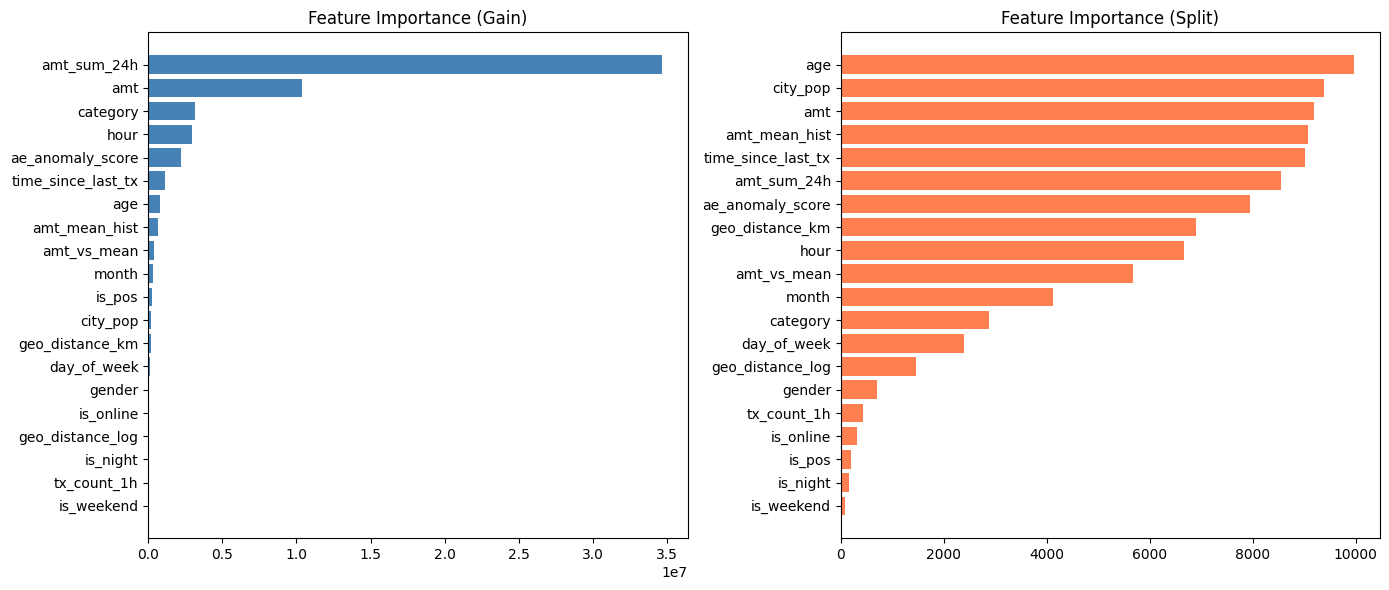


Top 10 by Gain:
           feature  importance_gain
       amt_sum_24h     3.464516e+07
               amt     1.036186e+07
          category     3.143247e+06
              hour     2.929987e+06
  ae_anomaly_score     2.198269e+06
time_since_last_tx     1.119681e+06
               age     8.247946e+05
     amt_mean_hist     6.362108e+05
       amt_vs_mean     3.608761e+05
             month     3.504655e+05


In [ ]:
# LightGBM native feature importance
importance_df = pd.DataFrame({
    'feature': best_model.feature_name(),
    'importance_gain': best_model.feature_importance(importance_type='gain'),
    'importance_split': best_model.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gain
axes[0].barh(importance_df['feature'], importance_df['importance_gain'], color='steelblue')
axes[0].set_title('Feature Importance (Gain)')
axes[0].invert_yaxis()

# Split
imp_split = importance_df.sort_values('importance_split', ascending=False)
axes[1].barh(imp_split['feature'], imp_split['importance_split'], color='coral')
axes[1].set_title('Feature Importance (Split)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 by Gain:")
print(importance_df[['feature', 'importance_gain']].head(10).to_string(index=False))

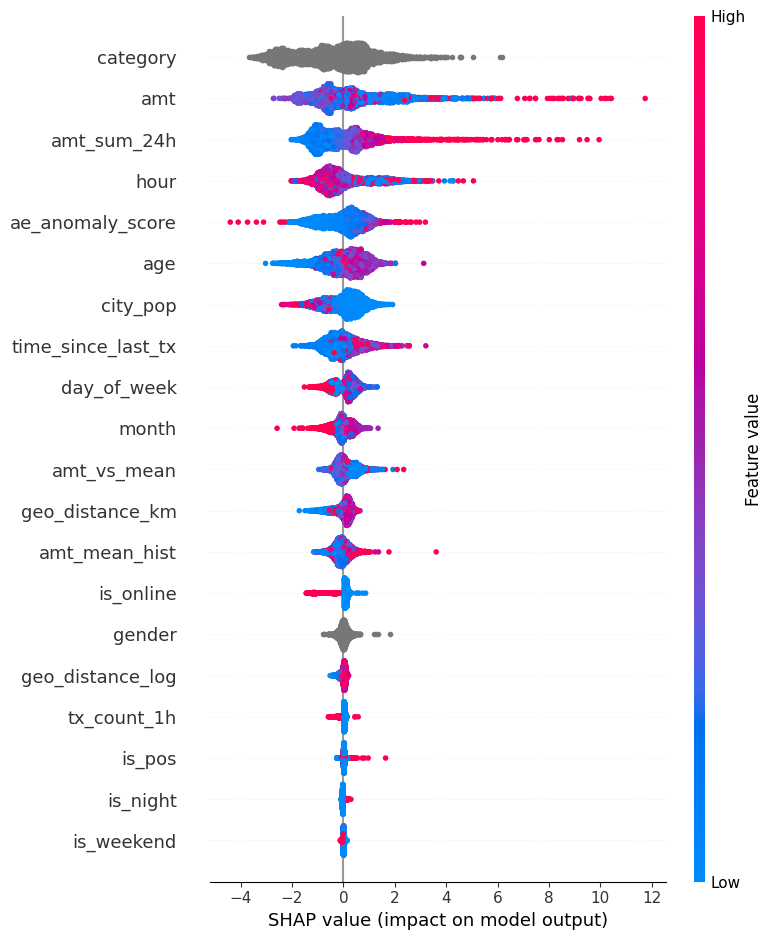

In [ ]:
# SHAP analizi (TreeSHAP — LightGBM ile çok hızlı)
import shap

# Sample üzerinden hesapla (full set çok yavaş olabilir)
SHAP_SAMPLE = 5000
shap_idx = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap = X_test.iloc[shap_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot
shap.summary_plot(shap_values, X_shap, show=True)

## 7) PR Curve & Threshold Analysis

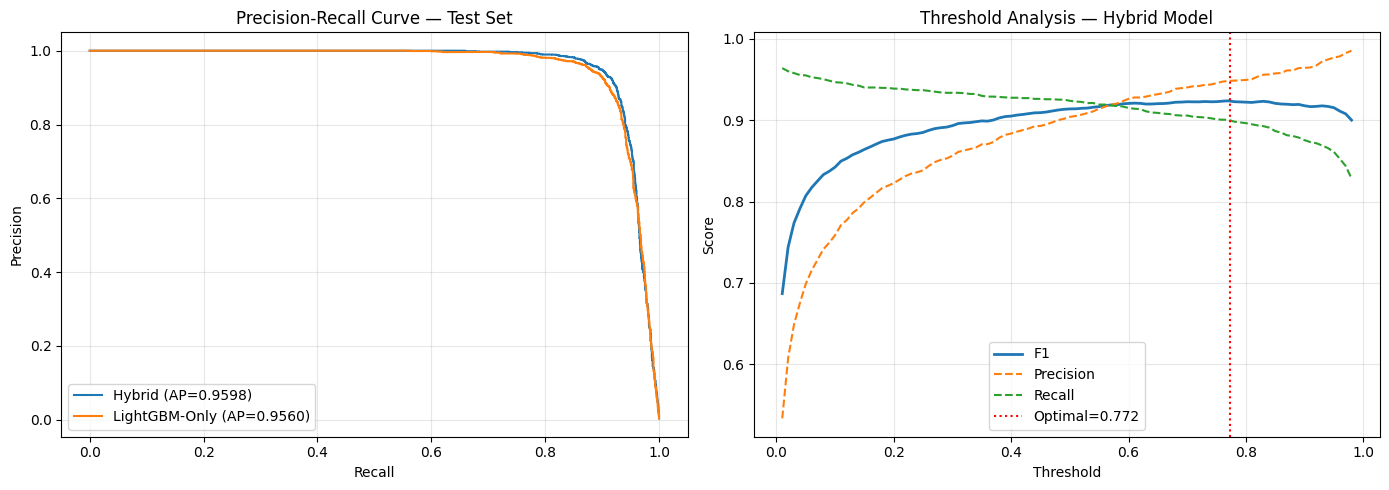

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve — Hybrid vs Base
for label, results in [('Hybrid', opt_results_test), ('LightGBM-Only', base_only_test)]:
    prec, rec, _ = precision_recall_curve(y_test, results['y_prob'])
    ap = average_precision_score(y_test, results['y_prob'])
    axes[0].plot(rec, prec, label=f'{label} (AP={ap:.4f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — Test Set')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Threshold vs F1/Precision/Recall
y_prob_test = opt_results_test['y_prob']
thresholds_range = np.arange(0.01, 0.99, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds_range:
    y_pred_t = (y_prob_test >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

axes[1].plot(thresholds_range, f1s, label='F1', linewidth=2)
axes[1].plot(thresholds_range, precs, label='Precision', linestyle='--')
axes[1].plot(thresholds_range, recs, label='Recall', linestyle='--')
axes[1].axvline(opt_results_test['threshold'], color='red', linestyle=':', label=f"Optimal={opt_results_test['threshold']:.3f}")
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Threshold Analysis — Hybrid Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Model & Artefact Kaydetme

In [ ]:
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Model
model_path = os.path.join(MODEL_SAVE_DIR, "lgbm_model.pkl")
joblib.dump(best_model, model_path)
print(f"✅ Model saved: {model_path}")

# Feature contract
feature_contract = {
    "lgbm_features_hybrid": LGBM_FEATURES_HYBRID,
    "lgbm_features_base": LGBM_FEATURES_BASE,
    "categorical_features": CATEGORICAL_FEATURES,
    "hybrid_features": HYBRID_FEATURES,
    "target": TARGET,
    "best_params": best_params,
    "best_iteration": best_model.best_iteration,
    "optimal_threshold": float(opt_results_test['threshold']),
    "dataset": "sparkov_credit_card_fraud"
}

contract_path = os.path.join(MODEL_SAVE_DIR, "lgbm_feature_contract.json")
with open(contract_path, 'w') as f:
    json.dump(feature_contract, f, indent=2, default=str)
print(f"✅ Feature contract saved: {contract_path}")

# Training report
training_report = {
    "dataset": "sparkov_credit_card_fraud",
    "train_size": len(df_train),
    "valid_size": len(df_valid),
    "test_size": len(df_test),
    "fraud_rate_train": float(df_train[TARGET].mean()),
    "optuna_trials": N_TRIALS,
    "best_iteration": best_model.best_iteration,
    "results": {
        "hybrid_test": {k: float(v) for k, v in opt_results_test.items() if k != 'y_prob'},
        "base_only_test": {k: float(v) for k, v in base_only_test.items() if k != 'y_prob'},
        "hybrid_valid": {k: float(v) for k, v in opt_results_valid.items() if k != 'y_prob'},
    },
    "ablation": {
        "ae_contribution_pr_auc": float(opt_results_test['pr_auc'] - base_only_test['pr_auc']),
        "ae_contribution_roc_auc": float(opt_results_test['roc_auc'] - base_only_test['roc_auc']),
    }
}

report_path = os.path.join(MODEL_SAVE_DIR, "training_report.json")
with open(report_path, 'w') as f:
    json.dump(training_report, f, indent=2)
print(f"✅ Training report saved: {report_path}")

✅ Model saved: /content/drive/MyDrive/thesis/models/lgbm_model.pkl
✅ Feature contract saved: /content/drive/MyDrive/thesis/models/lgbm_feature_contract.json
✅ Training report saved: /content/drive/MyDrive/thesis/models/training_report.json


## Özet

**Üretilen artefaktlar:**
- `lgbm_model.pkl` — Eğitilmiş LightGBM modeli (Optuna ile optimize edilmiş)
- `lgbm_feature_contract.json` — Feature listesi, parametreler, optimal threshold
- `training_report.json` — Tüm metrikler, ablation sonuçları

**Sonraki adımlar:**
1. XAI katmanı (TreeSHAP detaylı, DiCE/NICE counterfactual)
2. Drift monitoring (PSI/KL divergence)
3. Neo4j graph analytics entegrasyonu
4. Kafka streaming pipeline entegrasyonu
5. End-to-end system integration + dashboard

## TreeSHAP Entegrasyonu — Hibrit Fraud Detection Pipeline (XAI Katmanı)

- Bu notebook, eğitilmiş LightGBM modelinin üzerine TreeSHAP açıklanabilirlik katmanını ekler. Sparkov Credit Card Transactions dataseti için tasarlanmıştır.

**Ön koşullar:**
-   train_lightgbm.ipynb çalıştırılmış ve lgbm_model eğitilmiş olmalı
-   Feature-engineered DataFrame (df_test veya df_scored) mevcut olmalı
-   Eğitilmiş LightGBM modeli bellekte veya .pkl olarak disk üzerinde olmalı

**Çıktılar:**
-   1. Global feature importance (bar plot + JSON)
-   2. Her tahmin için local SHAP açıklamaları (waterfall, force)
-   3. Kafka-ready JSON formatında Top-N feature katkıları
-   4. SHAP summary plot (beeswarm)
-   5. Latency benchmark (gerçek zamanlı uygunluk testi)


# CELL 1: Imports ve Kurulum

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import json
import time
import warnings
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings("ignore")

# SHAP JS visualization (Colab notebook'larda force plot için gerekli)
shap.initjs()

print("✅ Imports başarılı")
print(f"   SHAP version: {shap.__version__}")
print(f"   LightGBM version: {lgb.__version__}")

✅ Imports başarılı
   SHAP version: 0.51.0
   LightGBM version: 4.6.0



## CELL 2: Konfigürasyon ve Feature Contract

- ÖNEMLİ: Bu feature listesini kendi train_lightgbm.ipynb'deki LGBM_FEATURES
- ile birebir eşleştir. Aşağıdaki liste Sparkov dataseti için tasarlanmıştır.
- Eğer farklı feature'lar kullandıysan, buradan güncelle.

### --- Sparkov Dataseti için LightGBM Feature Seti ---
- Senin mevcut pipeline'ında kullandığın feature'lar neyse ONLARI yaz.
- Aşağıdaki liste, Sparkov + feature engineering sonrası beklenen feature set.

In [ ]:
"""LGBM_FEATURES = [
    # (A) Transaction / Behavioral
    "amt",                          # İşlem tutarı
    "amt_zscore",                   # Tutar z-skoru (kişiye özel)
    "card_avg_amt",                 # Kart bazında ortalama tutar
    "card_std_amt",                 # Kart bazında tutar std
    "amt_to_avg_ratio",             # amt / card_avg_amt oranı

    # (B) Temporal
    "txn_hour",                     # İşlem saati (0-23)
    "txn_day_of_week",              # Haftanın günü (0-6)
    "is_weekend",                   # Hafta sonu mu?
    "is_night",                     # Gece işlemi mi? (22:00-06:00)

    # (C) Frequency / Velocity
    "card_txn_count_1h",            # Son 1 saatteki işlem sayısı
    "card_txn_count_24h",           # Son 24 saatteki işlem sayısı
    "time_since_last_txn",          # Son işlemden bu yana geçen süre (sn)

    # (D) Geo / Distance
    "merchant_to_card_distance_km", # Kart sahibi-merchant mesafesi (km)
    "geo_risk_log",                 # Log-dönüştürülmüş geo risk skoru

    # (E) Category (encoded)
    "category_encoded",             # Merchant kategori (label/target encoded)

    # (F) Hybrid — Autoencoder'dan gelen skor
    "ae_anomaly_score",             # AE reconstruction error (normalize edilmiş)
]"""


LGBM_FEATURES = [
    "amt",
    "age",
    "city_pop",
    "geo_distance_km",
    "geo_distance_log",
    "time_since_last_tx",
    "tx_count_1h",
    "amt_sum_24h",
    "amt_mean_hist",
    "amt_vs_mean",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_night",
    "is_online",
    "is_pos",
    "category",
    "gender",
    "ae_anomaly_score",
]

# Kafka JSON çıktısında kaç feature gösterilecek
TOP_N_FEATURES = 5

# SHAP hesaplama için maksimum sample sayısı (bellek yönetimi)
MAX_SHAP_SAMPLES = 50_000

print(f"✅ Feature contract yüklendi: {len(LGBM_FEATURES)} feature")
print(f"   Top-N ayarı: {TOP_N_FEATURES}")
print(f"   Max SHAP samples: {MAX_SHAP_SAMPLES:,}")

✅ Feature contract yüklendi: 20 feature
   Top-N ayarı: 5
   Max SHAP samples: 50,000


## CELL 3: Model ve Veri Yükleme

- Bu hücreyi kendi notebook ortamına göre düzenle.
- Seçenek A: Model bellekte zaten varsa (train_lightgbm.ipynb sonrası)
- Seçenek B: Diskten yükleme

### --- Seçenek A: Model bellekte (train sonrası aynı session'da çalışıyorsan) ---
- lgbm_model zaten tanımlı olmalı. Kontrol:

In [ ]:
try:
    _ = lgbm_model.num_trees()
    print(f"✅ LightGBM modeli bellekte mevcut ({lgbm_model.num_trees()} tree)")
except NameError:
    print("⚠️  lgbm_model bulunamadı — diskten yükleniyor...")
    # --- Seçenek B: Diskten yükle ---
    import joblib
    lgbm_model = joblib.load("/content/drive/MyDrive/thesis/models/lgbm_model.pkl")
    # veya LightGBM native format:
    # lgbm_model = lgb.Booster(model_file="/content/models/lgbm_model.txt")
    print(f"✅ Model diskten yüklendi ({lgbm_model.num_trees()} tree)")

# --- Veri Yükleme ---
# df_test veya df_scored zaten bellekte olmalı.
# Eğer yoksa, feature-engineered CSV'den yükle:
try:
    _ = df_test.shape
    print(f"✅ Test verisi bellekte: {df_test.shape}")
except NameError:
    print("⚠️  df_test bulunamadı — diskten yükleniyor...")
    df_test = pd.read_csv("/content/data/sparkov_test_featured.csv")
    print(f"✅ Test verisi yüklendi: {df_test.shape}")

# Feature matrix ve label'ları ayır
X_test = df_test[LGBM_FEATURES].copy()
y_test = df_test["is_fraud"].astype(int).values

print(f"\n📊 Veri Özeti:")
print(f"   X_test shape: {X_test.shape}")
print(f"   Fraud oranı: {y_test.mean():.4f} ({y_test.sum():,} / {len(y_test):,})")

⚠️  lgbm_model bulunamadı — diskten yükleniyor...
✅ Model diskten yüklendi (845 tree)
✅ Test verisi bellekte: (555719, 38)

📊 Veri Özeti:
   X_test shape: (555719, 20)
   Fraud oranı: 0.0039 (2,145 / 555,719)


## CELL 4: TreeSHAP Explainer Oluşturma


In [ ]:
print("🔄 TreeExplainer oluşturuluyor...")
t0 = time.time()

# TreeSHAP — LightGBM ile native entegrasyon (O(TLD) karmaşıklık)
# model_output="raw" → log-odds döner (probability yerine)
# model_output="probability" da kullanılabilir ama raw daha stabil
explainer = shap.TreeExplainer(
    lgbm_model,
    feature_perturbation="tree_path_dependent"  # TreeSHAP exact algorithm
)

t_explainer = time.time() - t0
print(f"✅ TreeExplainer oluşturuldu ({t_explainer:.2f}s)")

🔄 TreeExplainer oluşturuluyor...
✅ TreeExplainer oluşturuldu (2.61s)


## CELL 5: SHAP Değerlerini Hesapla (Test Seti)

In [ ]:
# Bellek yönetimi: çok büyük test setlerinde sample al
if len(X_test) > MAX_SHAP_SAMPLES:
    print(f"⚠️  Test seti büyük ({len(X_test):,}), {MAX_SHAP_SAMPLES:,} sample alınıyor...")
    # Stratified sampling: fraud oranını koru
    fraud_idx = np.where(y_test == 1)[0]
    normal_idx = np.where(y_test == 0)[0]

    n_fraud = min(len(fraud_idx), MAX_SHAP_SAMPLES // 2)
    n_normal = MAX_SHAP_SAMPLES - n_fraud

    sampled_idx = np.concatenate([
        np.random.choice(fraud_idx, n_fraud, replace=False),
        np.random.choice(normal_idx, n_normal, replace=False)
    ])
    np.random.shuffle(sampled_idx)

    X_shap = X_test.iloc[sampled_idx].reset_index(drop=True)
    y_shap = y_test[sampled_idx]
    print(f"   Sampled: {len(X_shap):,} ({y_shap.sum():,} fraud)")
else:
    X_shap = X_test.copy()
    y_shap = y_test.copy()

print(f"\n🔄 SHAP değerleri hesaplanıyor ({len(X_shap):,} sample)...")
t0 = time.time()

shap_values = explainer.shap_values(X_shap)

t_shap = time.time() - t0
print(f"✅ SHAP hesaplama tamamlandı ({t_shap:.2f}s)")
print(f"   Ortalama süre/sample: {(t_shap / len(X_shap)) * 1000:.2f}ms")

# LightGBM binary classification → shap_values list döner [class_0, class_1]
# Fraud (class=1) açıklamalarını al
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 = fraud
    print(f"   Binary classification: class_1 (fraud) SHAP values alındı")
else:
    shap_vals = shap_values
    print(f"   Single output SHAP values alındı")

print(f"   SHAP values shape: {shap_vals.shape}")
print(f"   Expected value (base): {explainer.expected_value}")

⚠️  Test seti büyük (555,719), 50,000 sample alınıyor...
   Sampled: 50,000 (2,145 fraud)

🔄 SHAP değerleri hesaplanıyor (50,000 sample)...
✅ SHAP hesaplama tamamlandı (192.12s)
   Ortalama süre/sample: 3.84ms
   Single output SHAP values alındı
   SHAP values shape: (50000, 20)
   Expected value (base): -16.225406136456154


## CELL 6: Global Feature Importance (Mean |SHAP|)

📊 Global Feature Importance (Mean |SHAP|):
   1. amt                                 1.381083  ██████████████████████████████
   2. category                            1.205885  ██████████████████████████
   3. amt_sum_24h                         1.059541  ███████████████████████
   4. hour                                0.789750  █████████████████
   5. ae_anomaly_score                    0.661777  ██████████████
   6. age                                 0.614954  █████████████
   7. city_pop                            0.534854  ███████████
   8. time_since_last_tx                  0.474613  ██████████
   9. day_of_week                         0.350995  ███████
  10. amt_vs_mean                         0.316426  ██████
  11. month                               0.279261  ██████
  12. amt_mean_hist                       0.253021  █████
  13. geo_distance_km                     0.251606  █████
  14. is_online                           0.221819  ████
  15. gender                          

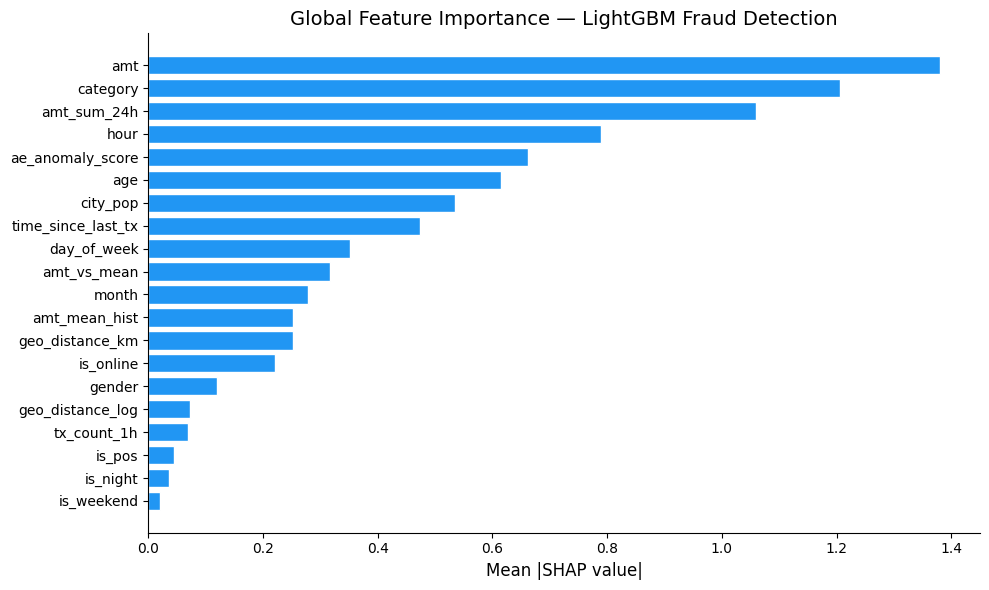

✅ Grafik kaydedildi: shap_global_importance.png
✅ JSON kaydedildi: global_feature_importance.json


In [ ]:
# Global importance: ortalama mutlak SHAP değeri
global_importance = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": LGBM_FEATURES,
    "mean_abs_shap": global_importance
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("📊 Global Feature Importance (Mean |SHAP|):")
print("=" * 55)
for i, row in importance_df.iterrows():
    bar_len = int(row["mean_abs_shap"] / importance_df["mean_abs_shap"].max() * 30)
    bar = "█" * bar_len
    print(f"  {i+1:2d}. {row['feature']:<35s} {row['mean_abs_shap']:.6f}  {bar}")

# --- Bar Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importance_df["feature"][::-1],
    importance_df["mean_abs_shap"][::-1],
    color="#2196F3",
    edgecolor="white"
)
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_title("Global Feature Importance — LightGBM Fraud Detection", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: shap_global_importance.png")

# --- JSON olarak kaydet ---
importance_json = importance_df.to_dict(orient="records")
with open("/content/drive/MyDrive/thesis/models/global_feature_importance.json", "w") as f:
    json.dump(importance_json, f, indent=2)
print("✅ JSON kaydedildi: global_feature_importance.json")

## CELL 7: SHAP Summary Plot (Beeswarm)

📊 SHAP Summary Plot (Beeswarm) oluşturuluyor...


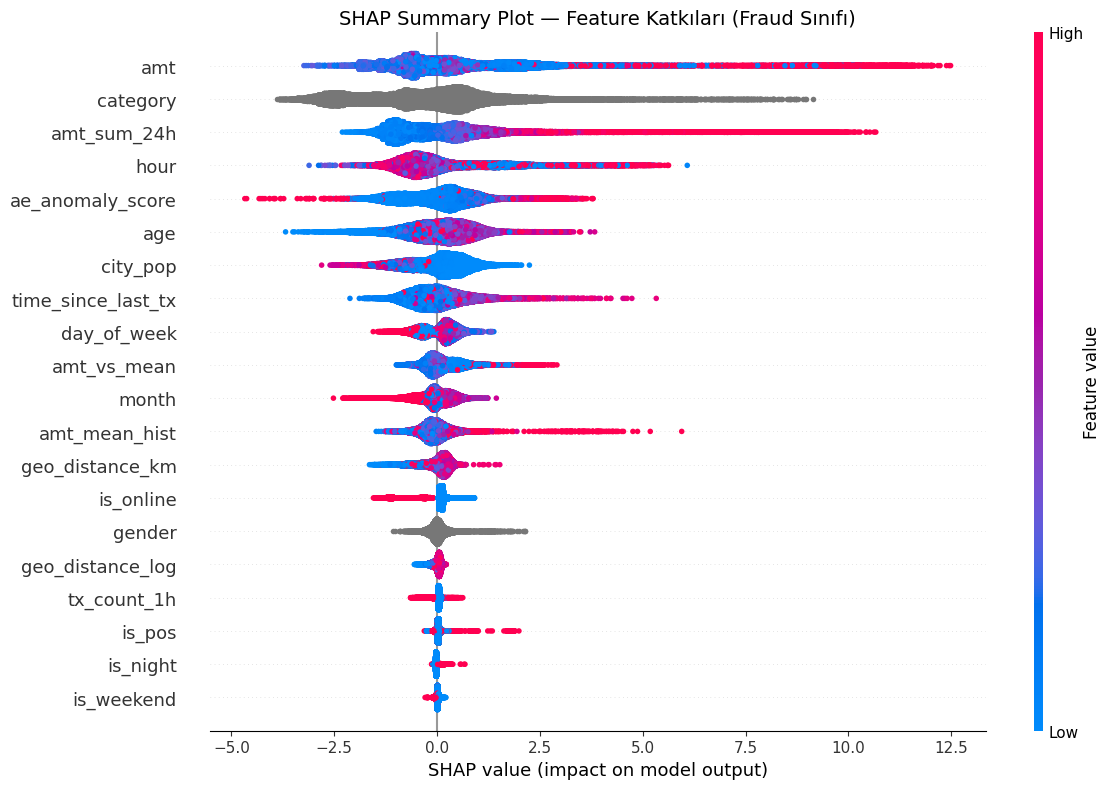

✅ Summary plot kaydedildi


In [ ]:
print("📊 SHAP Summary Plot (Beeswarm) oluşturuluyor...")

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=LGBM_FEATURES,
    show=False,
    max_display=len(LGBM_FEATURES),
    plot_size=(12, 8)
)
plt.title("SHAP Summary Plot — Feature Katkıları (Fraud Sınıfı)", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Summary plot kaydedildi")

## CELL 8: Tek İşlem Açıklaması — Waterfall Plot


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
FRAUD İŞLEM AÇIKLAMASI
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

  İşlem #34301 Açıklaması
  Gerçek: FRAUD | Tahmin: FRAUD (prob=1.0000)

  Feature Katkıları (en etkili → en az etkili):
  Feature                                  Değer         SHAP      Yön
  ----------------------------------- ---------- ------------ --------
  amt                                   882.1300   +10.174375  ↑ FRAUD
  amt_sum_24h                          5439.2300    +8.578088  ↑ FRAUD
  hour                                   23.0000    +4.551913  ↑ FRAUD
  ae_anomaly_score                        8.8133    +2.689538  ↑ FRAUD
  age                                    52.0000    +1.460862  ↑ FRAUD
  amt_vs_mean                             8.9054    +1.224990  ↑ FRAUD
  amt_mean_hist                          99.0562    +1.163862  ↑ FRAUD
  city_pop                              142.0000    +0.584277  ↑ FRAUD
  time_since_last_tx                    868.0000    +0.539722  ↑ FRAUD
  gender                       

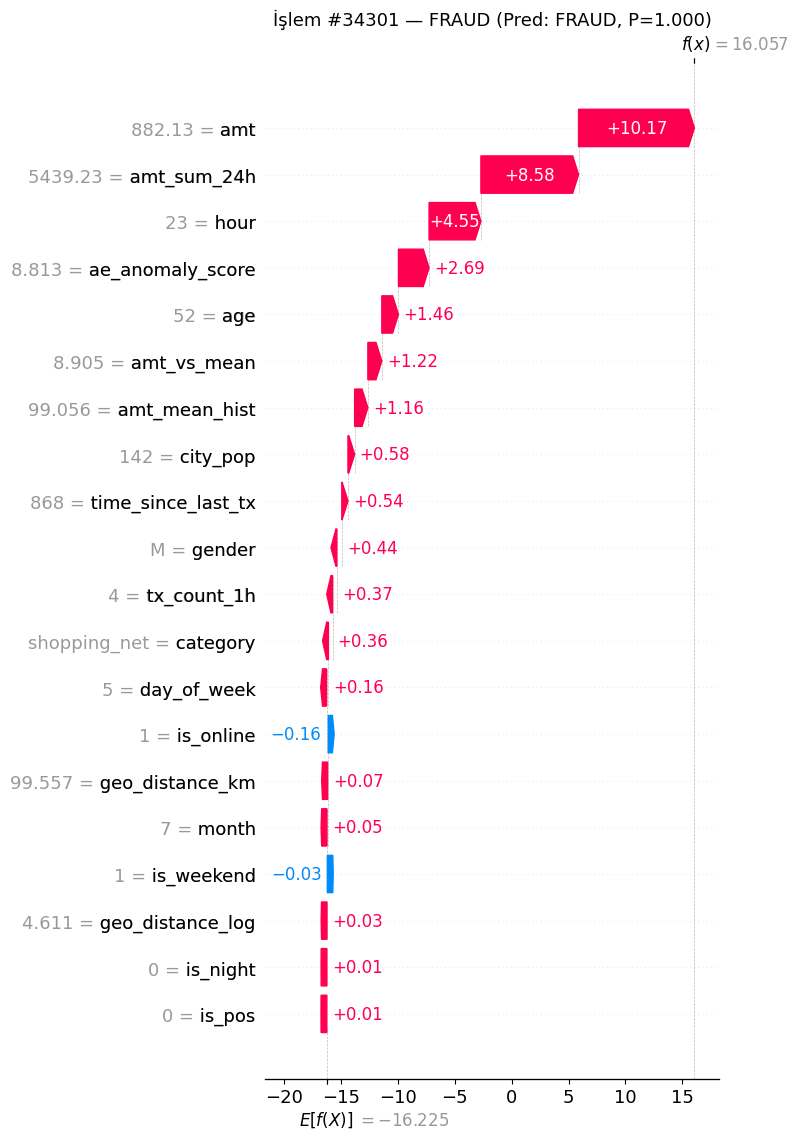


🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
NORMAL İŞLEM AÇIKLAMASI
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

  İşlem #36655 Açıklaması
  Gerçek: NORMAL | Tahmin: NORMAL (prob=0.0000)

  Feature Katkıları (en etkili → en az etkili):
  Feature                                  Değer         SHAP      Yön
  ----------------------------------- ---------- ------------ --------
  category                            entertainment    -1.113639 ↓ NORMAL
  amt_sum_24h                           151.0000    -1.067378 ↓ NORMAL
  hour                                   22.0000    +0.750180  ↑ FRAUD
  amt                                    64.8900    -0.649158 ↓ NORMAL
  city_pop                              427.0000    +0.535720  ↑ FRAUD
  time_since_last_tx                   4915.0000    -0.484648 ↓ NORMAL
  day_of_week                             0.0000    -0.413778 ↓ NORMAL
  age                                    69.0000    -0.300690 ↓ NORMAL
  month                                  10.0000    +0.240401  ↑ FRAUD
  amt_mean_hist          

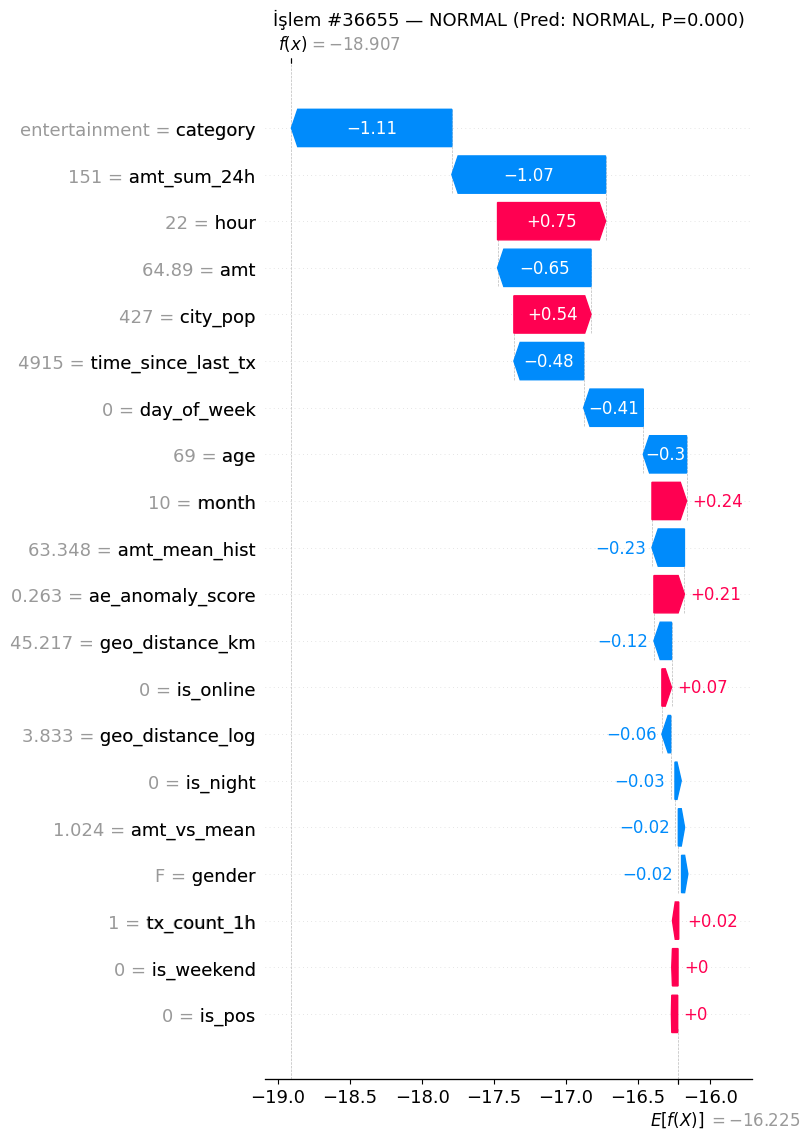

In [ ]:
def explain_single_transaction(idx, X_data, shap_vals_data, y_true, model,
                                feature_names, save_path=None):
    """
    Tek bir işlem için detaylı SHAP açıklaması üret.

    Args:
        idx: İşlem index'i (X_data içindeki satır numarası)
        X_data: Feature DataFrame
        shap_vals_data: SHAP values array
        y_true: Gerçek label'lar
        model: Eğitilmiş LightGBM model
        feature_names: Feature isimleri listesi
        save_path: Grafik kaydetme yolu (None ise kaydetmez)
    """
    # Tahmin al
    if hasattr(model, "predict_proba"):
        fraud_prob = model.predict_proba(X_data.iloc[[idx]])[0, 1]
    else:
        fraud_prob = model.predict(X_data.iloc[[idx]])[0]

    actual_label = "FRAUD" if y_true[idx] == 1 else "NORMAL"
    pred_label = "FRAUD" if fraud_prob >= 0.5 else "NORMAL"

    print(f"\n{'='*60}")
    print(f"  İşlem #{idx} Açıklaması")
    print(f"{'='*60}")
    print(f"  Gerçek: {actual_label} | Tahmin: {pred_label} (prob={fraud_prob:.4f})")
    print(f"{'='*60}")

    # Feature değerleri ve SHAP katkıları
    sv = shap_vals_data[idx]
    fv = X_data.iloc[idx].values

    contrib_df = pd.DataFrame({
        "feature": feature_names,
        "value": fv,
        "shap_value": sv,
        "abs_shap": np.abs(sv)
    }).sort_values("abs_shap", ascending=False)

    print("\n  Feature Katkıları (en etkili → en az etkili):")
    print(f"  {'Feature':<35s} {'Değer':>10s} {'SHAP':>12s} {'Yön':>8s}")
    print(f"  {'-'*35} {'-'*10} {'-'*12} {'-'*8}")
    for _, row in contrib_df.iterrows():
        direction = "↑ FRAUD" if row["shap_value"] > 0 else "↓ NORMAL"
        #print(f"  {row['feature']:<35s} {row['value']:>10.4f} {row['shap_value']:>+12.6f} {direction:>8s}")
        val = row['value']
        val_str = f"{val:>10.4f}" if isinstance(val, (int, float, np.floating, np.integer)) else f"{str(val):>10s}"
        print(f"  {row['feature']:<35s} {val_str} {row['shap_value']:>+12.6f} {direction:>8s}")

    # --- Waterfall Plot ---
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    explanation = shap.Explanation(
        values=sv,
        base_values=base_val,
        data=fv,
        feature_names=feature_names
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.waterfall(explanation, show=False, max_display=len(feature_names))
    plt.title(f"İşlem #{idx} — {actual_label} (Pred: {pred_label}, P={fraud_prob:.3f})",
              fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return contrib_df


# --- Örnek: Bir fraud ve bir normal işlem açıkla ---
fraud_indices = np.where(y_shap == 1)[0]
normal_indices = np.where(y_shap == 0)[0]

if len(fraud_indices) > 0:
    # En yüksek fraud prob'lu işlemi bul
    if hasattr(lgbm_model, "predict_proba"):
        probs = lgbm_model.predict_proba(X_shap.iloc[fraud_indices])[:, 1]
    else:
        probs = lgbm_model.predict(X_shap.iloc[fraud_indices])
    top_fraud_idx = fraud_indices[np.argmax(probs)]

    print("\n" + "🔴" * 20)
    print("FRAUD İŞLEM AÇIKLAMASI")
    print("🔴" * 20)
    fraud_contrib = explain_single_transaction(
        top_fraud_idx, X_shap, shap_vals, y_shap, lgbm_model,
        LGBM_FEATURES,
        save_path="/content/drive/MyDrive/thesis/models/shap_waterfall_fraud.png"
    )

if len(normal_indices) > 0:
    rand_normal_idx = np.random.choice(normal_indices)
    print("\n" + "🟢" * 20)
    print("NORMAL İŞLEM AÇIKLAMASI")
    print("🟢" * 20)
    normal_contrib = explain_single_transaction(
        rand_normal_idx, X_shap, shap_vals, y_shap, lgbm_model,
        LGBM_FEATURES,
        save_path="/content/drive/MyDrive/thesis/models/shap_waterfall_normal.png"
    )

## CELL 9: Force Plot (Interaktif — Notebook İçinde)

📊 Force Plot — Fraud işlem


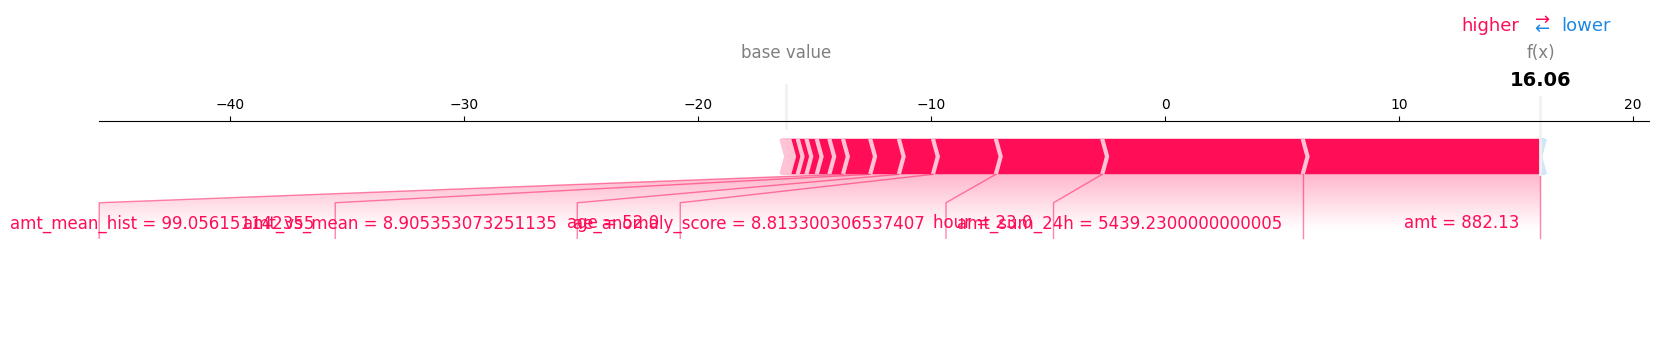

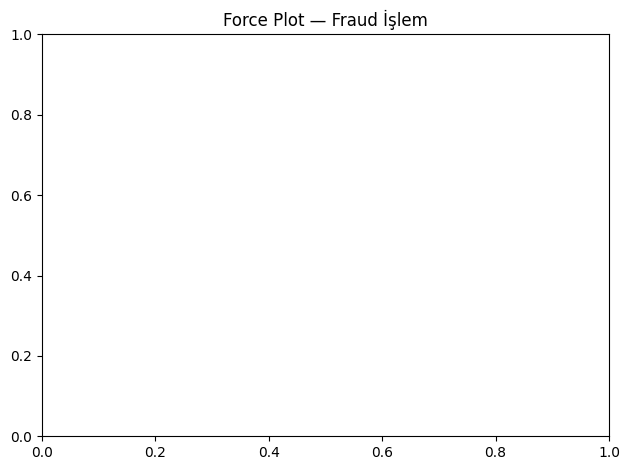

✅ Force plot kaydedildi


In [ ]:
if len(fraud_indices) > 0:
    print("📊 Force Plot — Fraud işlem")
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    shap.force_plot(
        base_val,
        shap_vals[top_fraud_idx],
        X_shap.iloc[top_fraud_idx],
        feature_names=LGBM_FEATURES,
        matplotlib=True
    )
    plt.title("Force Plot — Fraud İşlem", fontsize=12)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/thesis/models/shap_force_fraud.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Force plot kaydedildi")

## CELL 10: Kafka-Ready JSON Çıktısı — Top-N SHAP Katkıları

In [ ]:
def generate_shap_explanation_json(idx, X_data, shap_vals_data, model,
                                    feature_names, top_n=TOP_N_FEATURES):
    """
    Tek bir işlem için Kafka-ready JSON açıklama üret.

    Bu fonksiyon gerçek zamanlı pipeline'da her tahmin sonrası çağrılacak.
    Çıktı formatı Kafka'ya mesaj olarak gönderilmek üzere tasarlanmıştır.

    Returns:
        dict: JSON-serializable açıklama
    """
    sv = shap_vals_data[idx]
    fv = X_data.iloc[idx]

    # Tahmin
    if hasattr(model, "predict_proba"):
        fraud_prob = float(model.predict_proba(X_data.iloc[[idx]])[0, 1])
    else:
        fraud_prob = float(model.predict(X_data.iloc[[idx]])[0])

    # Base value
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = float(explainer.expected_value[1])
    else:
        base_val = float(explainer.expected_value)

    # Top-N etkili feature'lar
    abs_sv = np.abs(sv)
    top_indices = np.argsort(abs_sv)[::-1][:top_n]

    top_features = []
    for i in top_indices:
        top_features.append({
            "feature": feature_names[i],
            #"value": round(float(fv.iloc[i]), 6),
            "value": fv.iloc[i] if isinstance(fv.iloc[i], str) else round(float(fv.iloc[i]), 6),
            "shap_value": round(float(sv[i]), 6),
            "direction": "fraud" if sv[i] > 0 else "normal",
            "rank": int(len(top_features) + 1)
        })

    explanation = {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "fraud_probability": round(fraud_prob, 6),
        "risk_level": (
            "HIGH" if fraud_prob >= 0.7
            else "MEDIUM" if fraud_prob >= 0.3
            else "LOW"
        ),
        "shap_base_value": round(base_val, 6),
        "top_features": top_features,
        "total_features_used": len(feature_names),
        "model_version": "lgbm_hybrid_v1"
    }

    return explanation


# --- Örnek Çıktı: 5 Fraud İşlem ---
print("📋 Kafka-Ready JSON Çıktıları — Fraud İşlemler")
print("=" * 60)

sample_fraud_idx = fraud_indices[:5] if len(fraud_indices) >= 5 else fraud_indices

explanations_batch = []
for idx in sample_fraud_idx:
    expl = generate_shap_explanation_json(
        idx, X_shap, shap_vals, lgbm_model, LGBM_FEATURES
    )
    explanations_batch.append(expl)
    print(json.dumps(expl, indent=2, ensure_ascii=False))
    print("-" * 60)

# Batch kaydet
with open("/content/drive/MyDrive/thesis/models/shap_explanations_sample.json", "w") as f:
    json.dump(explanations_batch, f, indent=2, ensure_ascii=False)
print(f"\n✅ {len(explanations_batch)} açıklama JSON olarak kaydedildi")

📋 Kafka-Ready JSON Çıktıları — Fraud İşlemler
{
  "timestamp": "2026-03-24T19:25:24.183628Z",
  "fraud_probability": 0.979526,
  "risk_level": "HIGH",
  "shap_base_value": -16.225406,
  "top_features": [
    {
      "feature": "amt",
      "value": 1086.32,
      "shap_value": 8.865253,
      "direction": "fraud",
      "rank": 1
    },
    {
      "feature": "amt_sum_24h",
      "value": 1764.16,
      "shap_value": 4.471117,
      "direction": "fraud",
      "rank": 2
    },
    {
      "feature": "hour",
      "value": 22.0,
      "shap_value": 3.174998,
      "direction": "fraud",
      "rank": 3
    },
    {
      "feature": "ae_anomaly_score",
      "value": 4.337024,
      "shap_value": 2.352456,
      "direction": "fraud",
      "rank": 4
    },
    {
      "feature": "gender",
      "value": "M",
      "shap_value": 1.071026,
      "direction": "fraud",
      "rank": 5
    }
  ],
  "total_features_used": 20,
  "model_version": "lgbm_hybrid_v1"
}
-------------------------------

## CELL 11: Gerçek Zamanlı SHAP Hesaplama — Latency Benchmark

In [ ]:
print("⏱️  Gerçek Zamanlı SHAP Latency Benchmark")
print("=" * 55)

# Tek işlem SHAP hesaplama süresi
n_iterations = 100
single_times = []

for i in range(n_iterations):
    idx = np.random.choice(len(X_shap))
    sample = X_shap.iloc[[idx]]

    t0 = time.time()
    sv_single = explainer.shap_values(sample)
    t_single = (time.time() - t0) * 1000  # ms
    single_times.append(t_single)

single_times = np.array(single_times)

print(f"\n  Tek işlem SHAP hesaplama ({n_iterations} iterasyon):")
print(f"  {'Ortalama:':<20s} {single_times.mean():.2f} ms")
print(f"  {'Medyan (p50):':<20s} {np.percentile(single_times, 50):.2f} ms")
print(f"  {'p95:':<20s} {np.percentile(single_times, 95):.2f} ms")
print(f"  {'p99:':<20s} {np.percentile(single_times, 99):.2f} ms")
print(f"  {'Min:':<20s} {single_times.min():.2f} ms")
print(f"  {'Max:':<20s} {single_times.max():.2f} ms")

# JSON üretimi dahil toplam süre
total_times = []
for i in range(n_iterations):
    idx = np.random.choice(len(X_shap))
    sample = X_shap.iloc[[idx]]

    t0 = time.time()
    # SHAP hesapla
    sv_single = explainer.shap_values(sample)
    if isinstance(sv_single, list):
        sv_arr = sv_single[1][0]
    else:
        sv_arr = sv_single[0]

    # JSON üret
    abs_sv = np.abs(sv_arr)
    top_indices = np.argsort(abs_sv)[::-1][:TOP_N_FEATURES]
    _ = [{
        "feature": LGBM_FEATURES[i],
        "shap_value": float(sv_arr[i]),
    } for i in top_indices]

    t_total = (time.time() - t0) * 1000
    total_times.append(t_total)

total_times = np.array(total_times)

print(f"\n  SHAP + JSON üretimi (end-to-end):")
print(f"  {'Ortalama:':<20s} {total_times.mean():.2f} ms")
print(f"  {'p95:':<20s} {np.percentile(total_times, 95):.2f} ms")
print(f"  {'p99:':<20s} {np.percentile(total_times, 99):.2f} ms")

# Tez hedefi ile karşılaştır
target_latency = 200  # ms — tez önerisindeki hedef: p95 ≤ 200ms (toplam pipeline)
shap_p95 = np.percentile(total_times, 95)
shap_budget_pct = (shap_p95 / target_latency) * 100

print(f"\n  🎯 Tez Hedefi: p95 toplam pipeline ≤ {target_latency}ms")
print(f"  📊 SHAP bütçesi: {shap_p95:.2f}ms = toplam bütçenin %{shap_budget_pct:.1f}'ı")

if shap_p95 < 50:
    print("  ✅ MÜKEMMELı — SHAP çok hızlı, gerçek zamanlı pipeline'a uygun")
elif shap_p95 < 100:
    print("  ✅ İYİ — SHAP bütçe dahilinde")
elif shap_p95 < 150:
    print("  ⚠️  SINIRDA — Asenkron hesaplama düşünülebilir")
else:
    print("  🔴 YAVAŞ — Asenkron SHAP hesaplama gerekli (Kafka async)")

⏱️  Gerçek Zamanlı SHAP Latency Benchmark

  Tek işlem SHAP hesaplama (100 iterasyon):
  Ortalama:            31.43 ms
  Medyan (p50):        31.40 ms
  p95:                 32.98 ms
  p99:                 34.37 ms
  Min:                 30.03 ms
  Max:                 35.17 ms

  SHAP + JSON üretimi (end-to-end):
  Ortalama:            30.61 ms
  p95:                 31.38 ms
  p99:                 32.04 ms

  🎯 Tez Hedefi: p95 toplam pipeline ≤ 200ms
  📊 SHAP bütçesi: 31.38ms = toplam bütçenin %15.7'ı
  ✅ MÜKEMMELı — SHAP çok hızlı, gerçek zamanlı pipeline'a uygun


## CELL 12: SHAP Dependence Plots — En Önemli 4 Feature

📊 SHAP Dependence Plots — Top 4 Feature


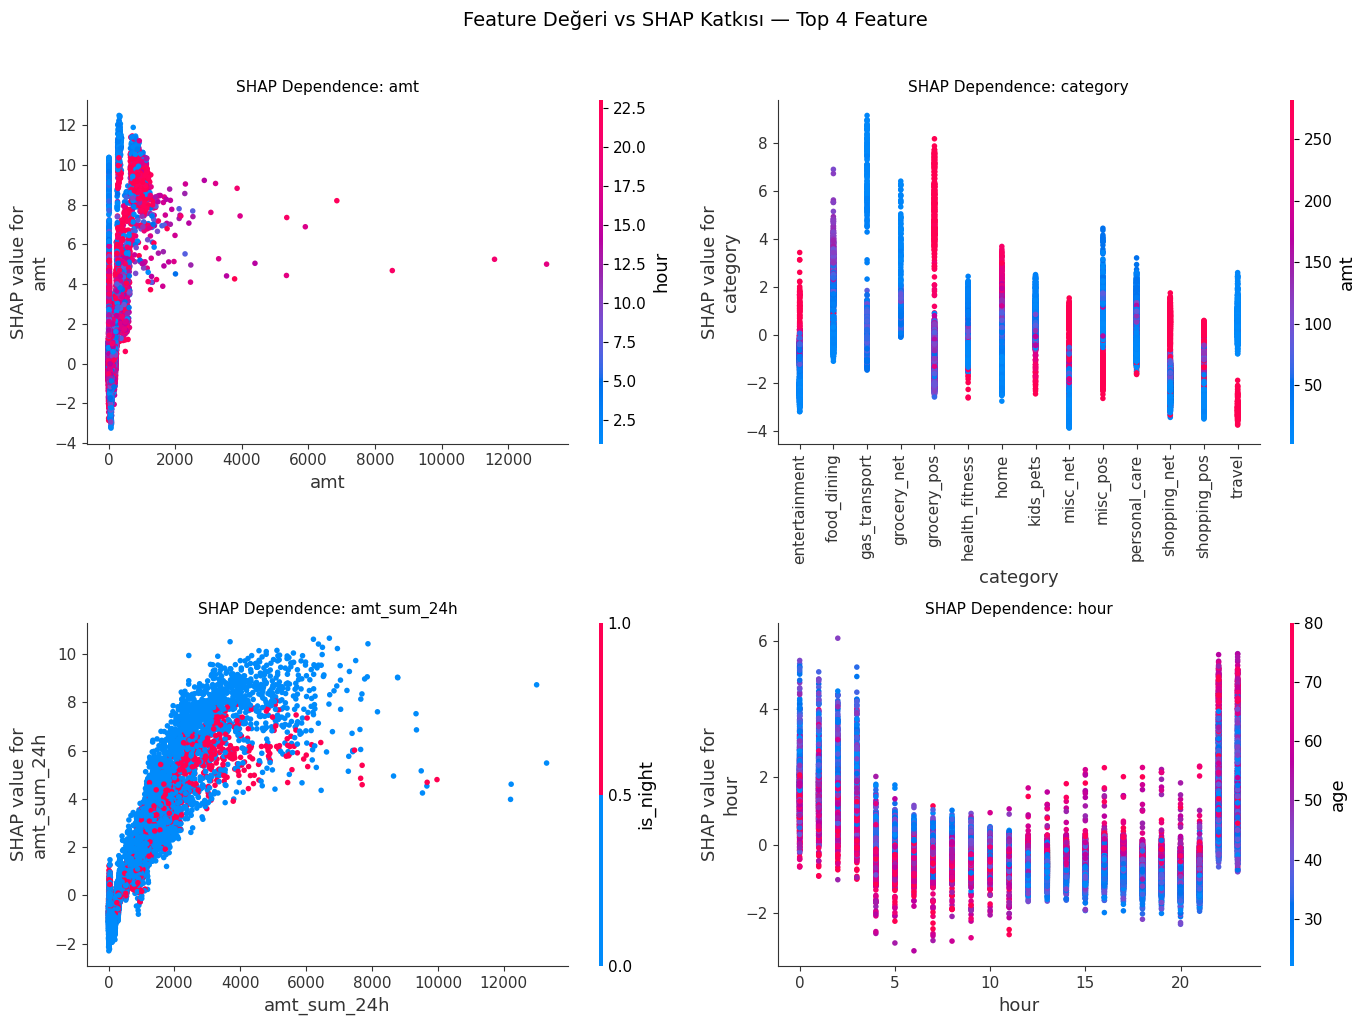

✅ Dependence plots kaydedildi


In [ ]:
print("📊 SHAP Dependence Plots — Top 4 Feature")

top4_features = importance_df["feature"].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4_features):
    feat_idx = LGBM_FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_vals,
        X_shap,
        feature_names=LGBM_FEATURES,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"SHAP Dependence: {feat}", fontsize=11)

plt.suptitle("Feature Değeri vs SHAP Katkısı — Top 4 Feature", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/shap_dependence_top4.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dependence plots kaydedildi")

## CELL 13: Fraud vs Normal SHAP Dağılımı Karşılaştırması

📊 Fraud vs Normal — SHAP Katkı Dağılımı

  Feature bazında Fraud vs Normal ortalama SHAP farkı:
  Feature                                  Fraud     Normal       Fark
  ----------------------------------- ---------- ---------- ----------
  amt                                    +8.5611    +0.2759    +8.2852
  amt_sum_24h                            +5.3370    +0.0361    +5.3009
  hour                                   +2.7308    -0.0686    +2.7993
  category                               +2.3884    -0.3967    +2.7851
  ae_anomaly_score                       +1.9251    +0.0019    +1.9232
  amt_vs_mean                            +1.1397    +0.0963    +1.0434
  age                                    +0.8025    +0.0018    +0.8007
  time_since_last_tx                     +0.4789    -0.0227    +0.5016
  amt_mean_hist                          +0.3419    -0.0543    +0.3962
  is_pos                                 +0.2243    +0.0226    +0.2017
  gender                                 +0.1577    

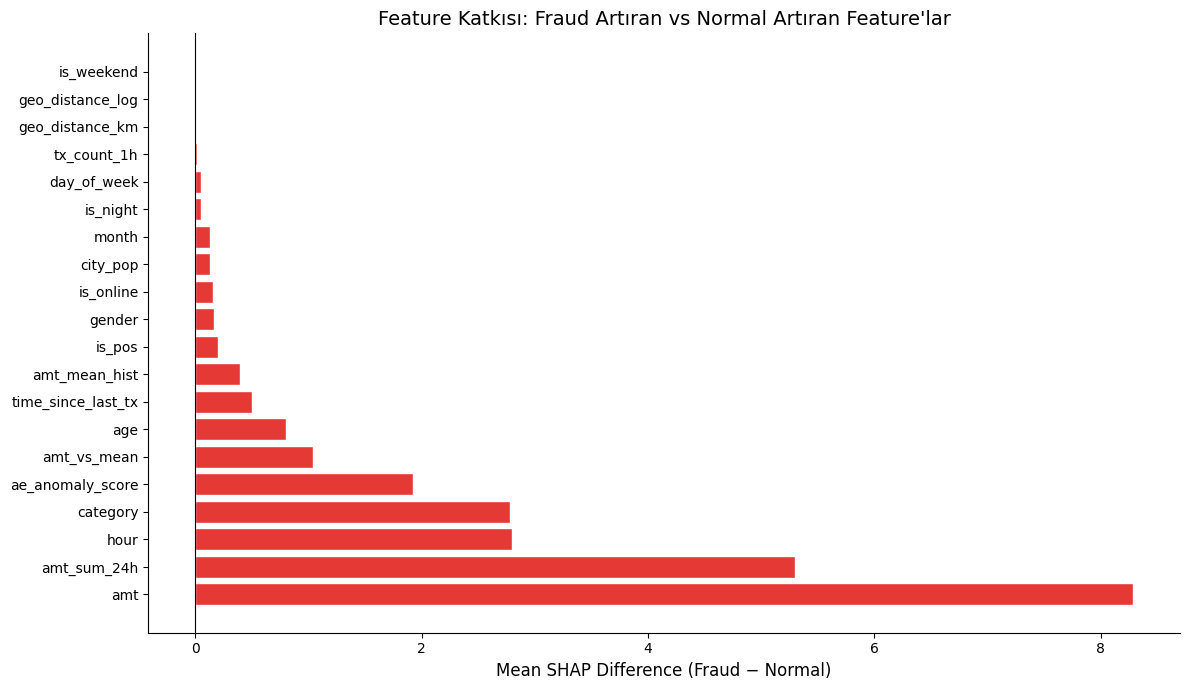

✅ Fraud vs Normal karşılaştırma grafiği kaydedildi


In [ ]:
print("📊 Fraud vs Normal — SHAP Katkı Dağılımı")

# Fraud ve normal işlemler için ortalama SHAP değerlerini karşılaştır
fraud_mask = y_shap == 1
normal_mask = y_shap == 0

fraud_mean_shap = shap_vals[fraud_mask].mean(axis=0)
normal_mean_shap = shap_vals[normal_mask].mean(axis=0)

comparison_df = pd.DataFrame({
    "feature": LGBM_FEATURES,
    "fraud_mean_shap": fraud_mean_shap,
    "normal_mean_shap": normal_mean_shap,
    "difference": fraud_mean_shap - normal_mean_shap
}).sort_values("difference", ascending=False)

print("\n  Feature bazında Fraud vs Normal ortalama SHAP farkı:")
print(f"  {'Feature':<35s} {'Fraud':>10s} {'Normal':>10s} {'Fark':>10s}")
print(f"  {'-'*35} {'-'*10} {'-'*10} {'-'*10}")
for _, row in comparison_df.iterrows():
    print(f"  {row['feature']:<35s} {row['fraud_mean_shap']:>+10.4f} "
          f"{row['normal_mean_shap']:>+10.4f} {row['difference']:>+10.4f}")

# --- Diverging Bar Plot ---
fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(comparison_df))
colors = ["#E53935" if d > 0 else "#43A047" for d in comparison_df["difference"]]

ax.barh(y_pos, comparison_df["difference"], color=colors, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df["feature"])
ax.set_xlabel("Mean SHAP Difference (Fraud − Normal)", fontsize=12)
ax.set_title("Feature Katkısı: Fraud Artıran vs Normal Artıran Feature'lar", fontsize=14)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/shap_fraud_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fraud vs Normal karşılaştırma grafiği kaydedildi")

## CELL 14: Sonuç Özeti ve Sonraki Adımlar

In [ ]:
print("\n" + "=" * 65)
print("  📊 TreeSHAP Entegrasyonu — Sonuç Özeti")
print("=" * 65)

print(f"""
  ✅ Yapılanlar:
     1. TreeExplainer oluşturuldu (LightGBM native entegrasyon)
     2. {len(X_shap):,} sample için SHAP değerleri hesaplandı
     3. Global feature importance çıkarıldı ve JSON'a kaydedildi
     4. Summary plot (beeswarm) oluşturuldu
     5. Waterfall plot — Fraud ve Normal işlem açıklamaları
     6. Force plot oluşturuldu
     7. Kafka-ready JSON açıklama formatı tanımlandı
     8. Dependence plots (Top 4 feature)
     9. Fraud vs Normal karşılaştırma
    10. xai_shap.py modülü oluşturuldu (gerçek zamanlı kullanım)

  📊 Performans:
     SHAP tek işlem latency (p95): {np.percentile(total_times, 95):.2f}ms
     Toplam pipeline bütçesi:      {target_latency}ms
     SHAP bütçe payı:             %{shap_budget_pct:.1f}

  📁 Kaydedilen Dosyalar:
     /content/plots/shap_global_importance.png
     /content/plots/shap_summary_beeswarm.png
     /content/plots/shap_waterfall_fraud.png
     /content/plots/shap_waterfall_normal.png
     /content/plots/shap_force_fraud.png
     /content/plots/shap_dependence_top4.png
     /content/plots/shap_fraud_vs_normal.png
     /content/models/global_feature_importance.json
     /content/models/shap_explanations_sample.json
     /content/src/ml/xai_shap.py

  🔜 Sonraki Adımlar:
     1. Counterfactual Explanations (DiCE/NICE) entegrasyonu
     2. PSI/KL Drift Monitoring modülü
     3. xai_shap.py → Kafka consumer entegrasyonu
     4. Neo4j graph analytics
""")


  📊 TreeSHAP Entegrasyonu — Sonuç Özeti

  ✅ Yapılanlar:
     1. TreeExplainer oluşturuldu (LightGBM native entegrasyon)
     2. 50,000 sample için SHAP değerleri hesaplandı
     3. Global feature importance çıkarıldı ve JSON'a kaydedildi
     4. Summary plot (beeswarm) oluşturuldu
     5. Waterfall plot — Fraud ve Normal işlem açıklamaları
     6. Force plot oluşturuldu
     7. Kafka-ready JSON açıklama formatı tanımlandı
     8. Dependence plots (Top 4 feature)
     9. Fraud vs Normal karşılaştırma
    10. xai_shap.py modülü oluşturuldu (gerçek zamanlı kullanım)

  📊 Performans:
     SHAP tek işlem latency (p95): 31.38ms
     Toplam pipeline bütçesi:      200ms
     SHAP bütçe payı:             %15.7

  📁 Kaydedilen Dosyalar:
     /content/plots/shap_global_importance.png
     /content/plots/shap_summary_beeswarm.png
     /content/plots/shap_waterfall_fraud.png
     /content/plots/shap_waterfall_normal.png
     /content/plots/shap_force_fraud.png
     /content/plots/shap_dependence_

###############################################################################
# Counterfactual Explanations — DiCE Entegrasyonu
**Bu notebook, eğitilmiş LightGBM fraud detection modeli için counterfactual
açıklamalar üretir: "Bu işlem hangi koşullarda normal sayılırdı?"**
#
## Ön koşullar (aynı Colab session'da):
**   - train_lightgbm.ipynb çalıştırılmış (lgbm_model, df_test mevcut)**
**   - treeshap_integration hücreleri çalıştırılmış (LGBM_FEATURES tanımlı)**

### Çıktılar:
**   1. Her fraud işlem için counterfactual senaryolar**
**   2. "Ne değişseydi normal olurdu?" JSON açıklamaları**
**   3. Değişim analizi görselleştirmeleri**
**   4. Kafka-ready counterfactual JSON formatı**
**   5. xai_counterfactual.py production modülü**



In [ ]:
# =============================================================================
# CELL 1: Imports ve DiCE Kurulumu
# =============================================================================

!pip install dice-ml --quiet  # Colab'da ilk çalıştırmada uncomment

import numpy as np
import pandas as pd
import dice_ml
import json
import time
import warnings
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings("ignore")

print("✅ Imports başarılı")
print(f"   DiCE import ok")

✅ Imports başarılı
   DiCE import ok


In [ ]:
# =============================================================================
# CELL 2: Feature Contract ve Kısıtlamalar (Constraints)
# =============================================================================

# SHAP notebook'uyla aynı feature listesi
LGBM_FEATURES = [
    "amt",
    "age",
    "city_pop",
    "geo_distance_km",
    "geo_distance_log",
    "time_since_last_tx",
    "tx_count_1h",
    "amt_sum_24h",
    "amt_mean_hist",
    "amt_vs_mean",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_night",
    "is_online",
    "is_pos",
    "category",
    "gender",
    "ae_anomaly_score",
]

TARGET = "is_fraud"

# --- Feature Tipleri (DiCE'ın ihtiyaç duyduğu bilgi) ---
CONTINUOUS_FEATURES = [
    "amt", "age", "city_pop", "geo_distance_km", "geo_distance_log",
    "time_since_last_tx", "tx_count_1h", "amt_sum_24h", "amt_mean_hist",
    "amt_vs_mean", "hour", "day_of_week", "month", "ae_anomaly_score",
]

CATEGORICAL_FEATURES = ["category", "gender"]

# Binary feature'lar (0/1) — DiCE bunları da categorical olarak görebilir
BINARY_FEATURES = ["is_weekend", "is_night", "is_online", "is_pos"]

# --- Değiştirilemez Feature'lar (Immutable / Frozen) ---
# Bu feature'lar counterfactual'da sabit kalmalı çünkü gerçek hayatta
# kart sahibi bunları değiştiremez veya değişmeleri mantıksız.
FROZEN_FEATURES = [
    "age",          # Kişinin yaşı değişmez
    "gender",       # Cinsiyet değişmez
    "city_pop",     # Şehir nüfusu kart sahibine bağlı değil
]

# --- Değişebilir Feature'lar ---
MUTABLE_FEATURES = [f for f in LGBM_FEATURES if f not in FROZEN_FEATURES]

# --- Feature Aralıkları (Permitted Ranges) ---
# DiCE'a "mantıklı" aralıklar vererek gerçekçi counterfactual üretmesini sağlarız
PERMITTED_RANGES = {
    "amt": [0.01, 5000],           # İşlem tutarı makul aralık
    "hour": [0, 23],               # Saat 0-23
    "day_of_week": [0, 6],         # Haftanın günü
    "month": [1, 12],              # Ay
    "tx_count_1h": [0, 20],        # Son 1 saatteki işlem sayısı
    "amt_sum_24h": [0, 10000],     # 24 saatlik toplam
    "ae_anomaly_score": [0, 20],   # AE skoru mantıklı aralık
}

print(f"✅ Feature contract yüklendi")
print(f"   Toplam feature: {len(LGBM_FEATURES)}")
print(f"   Continuous: {len(CONTINUOUS_FEATURES)}")
print(f"   Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"   Binary: {len(BINARY_FEATURES)}")
print(f"   Frozen (değiştirilemez): {len(FROZEN_FEATURES)} → {FROZEN_FEATURES}")
print(f"   Mutable (değiştirilebilir): {len(MUTABLE_FEATURES)}")

✅ Feature contract yüklendi
   Toplam feature: 20
   Continuous: 14
   Categorical: 2
   Binary: 4
   Frozen (değiştirilemez): 3 → ['age', 'gender', 'city_pop']
   Mutable (değiştirilebilir): 17


In [ ]:
# =============================================================================
# CELL 3: DiCE Data ve Model Objelerini Oluştur
# =============================================================================

# --- Veri Hazırlığı ---
# DiCE'a hem feature'ları hem target'ı içeren bir DataFrame lazım
# df_test zaten bellekte olmalı (train_lightgbm.ipynb'den)

try:
    _ = df_test.shape
    print(f"✅ df_test bellekte: {df_test.shape}")
except NameError:
    print("⚠️  df_test bulunamadı, diskten yükleniyor...")
    df_test = pd.read_csv("/content/data/sparkov_test_featured.csv")
    print(f"✅ df_test yüklendi: {df_test.shape}")

# DiCE için DataFrame: features + target
df_dice = df_test[LGBM_FEATURES + [TARGET]].copy()

# Target'ı integer yap (DiCE bunu bekler)
df_dice[TARGET] = df_dice[TARGET].astype(int)

print(f"   DiCE DataFrame shape: {df_dice.shape}")
print(f"   Fraud oranı: {df_dice[TARGET].mean():.4f}")

# --- DiCE Data Objesi ---
# continuous_features listesine binary'leri de ekle (DiCE için numeric)
dice_continuous = CONTINUOUS_FEATURES + BINARY_FEATURES

d = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=dice_continuous,
    outcome_name=TARGET
)
print("✅ DiCE Data objesi oluşturuldu")

# --- DiCE Model Objesi ---
# Her zaman wrapper kullan (try/except kaldır)
from sklearn.base import BaseEstimator, ClassifierMixin

class LGBMBoosterWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, booster):
        self.booster = booster
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=LGBM_FEATURES)

        X = X.copy()

        # Numeric sütunları cast et
        for col in CONTINUOUS_FEATURES + ['age', 'city_pop']:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce')

        # Binary sütunları cast et
        for col in BINARY_FEATURES:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce').astype(int)

        # Kategorik sütunları cast et
        for col in CATEGORICAL_FEATURES:
            if col in X.columns:
                X[col] = X[col].astype('category')

        preds = self.booster.predict(X)
        return np.column_stack([1 - preds, preds])


wrapped_model = LGBMBoosterWrapper(lgbm_model)
m = dice_ml.Model(model=wrapped_model, backend="sklearn", model_type="classifier")
print("✅ DiCE Model objesi oluşturuldu (Booster wrapper)")

✅ df_test bellekte: (555719, 38)
   DiCE DataFrame shape: (555719, 21)
   Fraud oranı: 0.0039
✅ DiCE Data objesi oluşturuldu
✅ DiCE Model objesi oluşturuldu (Booster wrapper)


In [ ]:
# =============================================================================
# CELL 4: DiCE Explainer Oluştur
# =============================================================================

# Counterfactual üretim yöntemi seçimi:
# - "random": Hızlı, ama kalitesi değişken
# - "genetic": Daha kaliteli, ama yavaş
# - "kdtree": Gerçek veri noktalarına yakın CF üretir (NICE benzeri)

METHOD = "random"  # Colab'da hız için "random" öneriyorum. Daha iyi sonuç için "genetic"

exp = dice_ml.Dice(d, m, method=METHOD)
print(f"✅ DiCE Explainer oluşturuldu (method={METHOD})")

✅ DiCE Explainer oluşturuldu (method=random)


In [ ]:
# =============================================================================
# CELL 5: Tek Fraud İşlem İçin Counterfactual Üret
# =============================================================================

# Fraud işlemleri bul
fraud_mask = df_dice[TARGET] == 1
fraud_indices = df_dice[fraud_mask].index.tolist()
print(f"📊 Test setinde {len(fraud_indices):,} fraud işlem mevcut")

fraud_indices = np.array(fraud_indices)

# Yüksek güvenli bir fraud işlem seç (model çok emin olsun)
fraud_samples = df_dice.loc[fraud_indices, LGBM_FEATURES]

if hasattr(lgbm_model, "predict_proba"):
    fraud_probs = lgbm_model.predict_proba(fraud_samples)[:, 1]
else:
    fraud_probs = lgbm_model.predict(fraud_samples)

# En yüksek fraud probability'li 10 işlemi al
top_fraud_idx = fraud_indices[np.argsort(fraud_probs)[::-1][:10]]

# İlk fraud işlem için counterfactual üret
query_instance = df_dice.loc[[top_fraud_idx[0]], LGBM_FEATURES]
original_prob = fraud_probs[np.argsort(fraud_probs)[::-1][0]]

print(f"\n🔴 Seçilen Fraud İşlem (index={top_fraud_idx[0]}):")
print(f"   Fraud probability: {original_prob:.4f}")
print(f"   Feature değerleri:")
for feat in LGBM_FEATURES:
    val = query_instance[feat].values[0]
    print(f"     {feat:<30s} = {val}")

# --- Counterfactual Üret ---
print(f"\n🔄 Counterfactual üretiliyor (method={METHOD})...")
t0 = time.time()

cf = exp.generate_counterfactuals(
    query_instance,
    total_CFs=4,                          # 4 alternatif senaryo üret
    desired_class="opposite",              # Fraud → Normal yönünde
    features_to_vary=MUTABLE_FEATURES,     # Sadece değiştirilebilir feature'lar
    permitted_range=PERMITTED_RANGES,       # Mantıklı değer aralıkları
)

t_cf = time.time() - t0
print(f"✅ Counterfactual üretildi ({t_cf:.2f}s)")

# Sonuçları göster
cf.visualize_as_dataframe(show_only_changes=True)

📊 Test setinde 2,145 fraud işlem mevcut

🔴 Seçilen Fraud İşlem (index=31374):
   Fraud probability: 1.0000
   Feature değerleri:
     amt                            = 882.13
     age                            = 52.0
     city_pop                       = 142
     geo_distance_km                = 99.55726967009262
     geo_distance_log               = 4.610727412661328
     time_since_last_tx             = 868.0
     tx_count_1h                    = 4.0
     amt_sum_24h                    = 5439.2300000000005
     amt_mean_hist                  = 99.056151142355
     amt_vs_mean                    = 8.905353073251135
     hour                           = 23
     day_of_week                    = 5
     month                          = 7
     is_weekend                     = 1
     is_night                       = 0
     is_online                      = 1
     is_pos                         = 0
     category                       = shopping_net
     gender                         = M
    

100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

✅ Counterfactual üretildi (4.76s)
Query instance (original outcome : 1)


,amt,age,city_pop,geo_distance_km,geo_distance_log,time_since_last_tx,tx_count_1h,amt_sum_24h,amt_mean_hist,amt_vs_mean,...,day_of_week,month,is_weekend,is_night,is_online,is_pos,category,gender,ae_anomaly_score,is_fraud
0,882.130005,52.0,142,99.557266,4.610727,868.0,4.0,5439.22998,99.056152,8.905354,...,5,7,1,0,1,0,shopping_net,M,8.8133,1



Diverse Counterfactual set (new outcome: 0)


,amt,age,city_pop,geo_distance_km,geo_distance_log,time_since_last_tx,tx_count_1h,amt_sum_24h,amt_mean_hist,amt_vs_mean,...,day_of_week,month,is_weekend,is_night,is_online,is_pos,category,gender,ae_anomaly_score,is_fraud
0,247.6,-,-,-,-,-,-,-,-,301.1,...,-,-,-,-,-,-,-,-,-,0
1,186.2,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0
2,-,-,-,-,-,-,-,33.2,-,-,...,-,-,-,-,-,-,personal_care,-,-,0
3,4447.7,-,-,-,-,-,-,33.2,-,-,...,-,-,-,-,-,-,personal_care,-,-,0


In [ ]:
# =============================================================================
# CELL 6: Counterfactual Sonuçlarını Analiz Et
# =============================================================================

def analyze_counterfactual(query_instance, cf_result, feature_names, model,
                           frozen_features=FROZEN_FEATURES):
    """
    Counterfactual sonuçlarını detaylı analiz et.

    Args:
        query_instance: Orijinal fraud işlem (DataFrame)
        cf_result: DiCE counterfactual sonucu
        feature_names: Feature listesi
        model: LightGBM model
        frozen_features: Değiştirilemez feature'lar

    Returns:
        list[dict]: Her CF senaryosu için değişim analizi
    """
    # Orijinal değerler
    orig_vals = query_instance.iloc[0]

    # CF DataFrame'i al
    cf_df = cf_result.cf_examples_list[0].final_cfs_df

    if cf_df is None or len(cf_df) == 0:
        print("⚠️  Counterfactual bulunamadı!")
        return []

    scenarios = []

    for cf_idx in range(len(cf_df)):
        cf_row = cf_df.iloc[cf_idx]

        # Tahmin al
        cf_features = cf_row[feature_names]
        if hasattr(model, "predict_proba"):
            cf_prob = model.predict_proba(pd.DataFrame([cf_features], columns=feature_names))[0, 1]
        else:
            cf_prob = model.predict(pd.DataFrame([cf_features], columns=feature_names))[0]

        # Hangi feature'lar değişti?
        changes = []
        for feat in feature_names:
            orig_val = orig_vals[feat]
            cf_val = cf_row[feat]

            # Değişim kontrolü (string ve numeric farklı)
            if isinstance(orig_val, str):
                if orig_val != cf_val:
                    changes.append({
                        "feature": feat,
                        "original": orig_val,
                        "counterfactual": cf_val,
                        "change_type": "categorical"
                    })
            else:
                if abs(float(orig_val) - float(cf_val)) > 1e-6:
                    pct_change = ((float(cf_val) - float(orig_val)) / (abs(float(orig_val)) + 1e-10)) * 100
                    changes.append({
                        "feature": feat,
                        "original": round(float(orig_val), 4),
                        "counterfactual": round(float(cf_val), 4),
                        "difference": round(float(cf_val) - float(orig_val), 4),
                        "pct_change": round(pct_change, 2),
                        "change_type": "numeric"
                    })

        scenarios.append({
            "scenario_id": cf_idx + 1,
            "original_fraud_prob": round(float(fraud_probs[np.argsort(fraud_probs)[::-1][0]]), 6),
            "counterfactual_fraud_prob": round(float(cf_prob), 6),
            "num_changes": len(changes),
            "changes": changes
        })

    return scenarios


# --- Analiz ---
scenarios = analyze_counterfactual(query_instance, cf, LGBM_FEATURES, wrapped_model)

print("\n" + "=" * 70)
print("  COUNTERFACTUAL ANALİZİ: Bu işlem ne olsaydı normal sayılırdı?")
print("=" * 70)

for s in scenarios:
    print(f"\n  📋 Senaryo #{s['scenario_id']}")
    print(f"     Orijinal fraud olasılığı:       {s['original_fraud_prob']:.4f}")
    print(f"     Counterfactual fraud olasılığı:  {s['counterfactual_fraud_prob']:.4f}")
    print(f"     Değişen feature sayısı:          {s['num_changes']}")
    print(f"     {'─' * 60}")

    for c in s["changes"]:
        if c["change_type"] == "categorical":
            print(f"     {c['feature']:<30s}: {c['original']} → {c['counterfactual']}")
        else:
            arrow = "↓" if c["difference"] < 0 else "↑"
            print(f"     {c['feature']:<30s}: {c['original']:>10.2f} → {c['counterfactual']:>10.2f}"
                  f"  ({arrow} {c['pct_change']:+.1f}%)")


  COUNTERFACTUAL ANALİZİ: Bu işlem ne olsaydı normal sayılırdı?

  📋 Senaryo #1
     Orijinal fraud olasılığı:       1.0000
     Counterfactual fraud olasılığı:  0.0124
     Değişen feature sayısı:          3
     ────────────────────────────────────────────────────────────
     amt                           :     882.13 →     247.60  (↓ -71.9%)
     amt_vs_mean                   :       8.91 →     301.10  (↑ +3281.1%)
     hour                          :      23.00 →       5.00  (↓ -78.3%)

  📋 Senaryo #2
     Orijinal fraud olasılığı:       1.0000
     Counterfactual fraud olasılığı:  0.0933
     Değişen feature sayısı:          2
     ────────────────────────────────────────────────────────────
     amt                           :     882.13 →     186.20  (↓ -78.9%)
     hour                          :      23.00 →      19.00  (↓ -17.4%)

  📋 Senaryo #3
     Orijinal fraud olasılığı:       1.0000
     Counterfactual fraud olasılığı:  0.2343
     Değişen feature sayısı:          2
 

In [ ]:
# =============================================================================
# CELL 7: Birden Fazla Fraud İşlem İçin Batch Counterfactual
# =============================================================================

print("🔄 Batch counterfactual üretiliyor (5 fraud işlem)...")

batch_results = []
n_samples = min(5, len(top_fraud_idx))

for i in range(n_samples):
    idx = top_fraud_idx[i]
    query = df_dice.loc[[idx], LGBM_FEATURES]

    print(f"\n  İşlem {i+1}/{n_samples} (index={idx})...", end=" ")
    t0 = time.time()

    try:
        cf_result = exp.generate_counterfactuals(
            query,
            total_CFs=3,
            desired_class="opposite",
            features_to_vary=MUTABLE_FEATURES,
            permitted_range=PERMITTED_RANGES,
        )
        t_single = time.time() - t0
        print(f"✅ ({t_single:.2f}s)")

        analysis = analyze_counterfactual(query, cf_result, LGBM_FEATURES, wrapped_model)
        batch_results.append({
            "transaction_index": int(idx),
            "scenarios": analysis
        })
    except Exception as e:
        print(f"⚠️ Hata: {e}")
        continue

print(f"\n✅ {len(batch_results)} işlem için counterfactual üretildi")

🔄 Batch counterfactual üretiliyor (5 fraud işlem)...

  İşlem 1/5 (index=31374)... 

100%|██████████| 1/1 [00:04<00:00,  4.64s/it]


✅ (4.65s)

  İşlem 2/5 (index=116414)... 

100%|██████████| 1/1 [00:04<00:00,  4.54s/it]


✅ (4.54s)

  İşlem 3/5 (index=119156)... 

100%|██████████| 1/1 [00:04<00:00,  4.57s/it]


✅ (4.57s)

  İşlem 4/5 (index=297827)... 

100%|██████████| 1/1 [00:04<00:00,  4.50s/it]


✅ (4.51s)

  İşlem 5/5 (index=342981)... 

100%|██████████| 1/1 [00:04<00:00,  4.55s/it]

✅ (4.55s)

✅ 5 işlem için counterfactual üretildi



📊 Counterfactual'larda En Sık Değişen Feature'lar:
  Feature                         Değişim Sayısı  Ort. % Değişim
  ────────────────────────────── ─────────────── ───────────────
  hour                                        12           65.4%  ████████████████████
  amt_sum_24h                                 10           82.9%  ████████████████
  category                                     8            0.0%  █████████████
  is_weekend                                   2          100.0%  ███
  amt                                          2           75.5%  ███
  amt_vs_mean                                  2         2369.7%  ███
  time_since_last_tx                           1       357450.4%  █
  geo_distance_log                             1           91.0%  █
  geo_distance_km                              1           91.6%  █
  month                                        1           20.0%  █


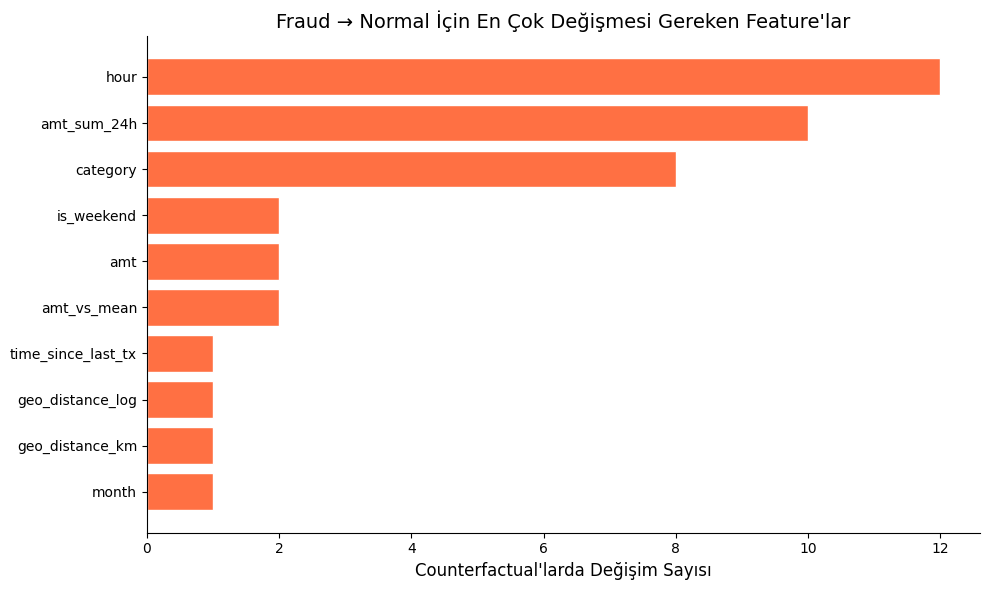

✅ Grafik kaydedildi


In [ ]:
# =============================================================================
# CELL 8: En Sık Değişen Feature'lar — Counterfactual Analizi
# =============================================================================

# Hangi feature'lar en sık değişiyor?
# Bu, "fraud'u normal yapmak için en kritik neler değişmeli" sorusunu cevaplar

change_counts = {}
change_magnitudes = {}

for result in batch_results:
    for scenario in result["scenarios"]:
        for change in scenario["changes"]:
            feat = change["feature"]
            change_counts[feat] = change_counts.get(feat, 0) + 1
            if change["change_type"] == "numeric":
                if feat not in change_magnitudes:
                    change_magnitudes[feat] = []
                change_magnitudes[feat].append(abs(change["pct_change"]))

# Sıralama
sorted_counts = sorted(change_counts.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Counterfactual'larda En Sık Değişen Feature'lar:")
print("=" * 65)
print(f"  {'Feature':<30s} {'Değişim Sayısı':>15s} {'Ort. % Değişim':>15s}")
print(f"  {'─' * 30} {'─' * 15} {'─' * 15}")

for feat, count in sorted_counts:
    avg_mag = np.mean(change_magnitudes.get(feat, [0]))
    bar = "█" * int(count / max(c for _, c in sorted_counts) * 20)
    print(f"  {feat:<30s} {count:>15d} {avg_mag:>14.1f}%  {bar}")

# --- Bar Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
features_sorted = [f for f, _ in sorted_counts]
counts_sorted = [c for _, c in sorted_counts]

ax.barh(features_sorted[::-1], counts_sorted[::-1], color="#FF7043", edgecolor="white")
ax.set_xlabel("Counterfactual'larda Değişim Sayısı", fontsize=12)
ax.set_title("Fraud → Normal İçin En Çok Değişmesi Gereken Feature'lar", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/cf_most_changed_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi")

In [ ]:
# =============================================================================
# CELL 9: Değişim Yönü Analizi — Feature Nasıl Değişmeli?
# =============================================================================

print("\n📊 Counterfactual Değişim Yönü Analizi:")
print("=" * 70)
print("  (Fraud işlemi normal yapmak için feature'ların hangi yönde değişmesi gerekiyor)")
print()

direction_analysis = {}

for result in batch_results:
    for scenario in result["scenarios"]:
        for change in scenario["changes"]:
            feat = change["feature"]
            if change["change_type"] == "numeric":
                direction = "azalmalı" if change["difference"] < 0 else "artmalı"
                if feat not in direction_analysis:
                    direction_analysis[feat] = {"azalmalı": 0, "artmalı": 0, "diffs": []}
                direction_analysis[feat][direction] += 1
                direction_analysis[feat]["diffs"].append(change["difference"])

for feat, info in sorted(direction_analysis.items(),
                          key=lambda x: x[1]["azalmalı"] + x[1]["artmalı"], reverse=True):
    total = info["azalmalı"] + info["artmalı"]
    dominant = "↓ AZALMALI" if info["azalmalı"] > info["artmalı"] else "↑ ARTMALI"
    avg_diff = np.mean(info["diffs"])
    print(f"  {feat:<30s} {dominant:<12s}  "
          f"(↓{info['azalmalı']} / ↑{info['artmalı']})  "
          f"Ort. değişim: {avg_diff:+.2f}")



📊 Counterfactual Değişim Yönü Analizi:
  (Fraud işlemi normal yapmak için feature'ların hangi yönde değişmesi gerekiyor)

  hour                           ↓ AZALMALI    (↓12 / ↑0)  Ort. değişim: -14.92
  amt_sum_24h                    ↓ AZALMALI    (↓10 / ↑0)  Ort. değişim: -3617.33
  is_weekend                     ↓ AZALMALI    (↓2 / ↑0)  Ort. değişim: -1.00
  amt                            ↑ ARTMALI     (↓1 / ↑1)  Ort. değişim: +400.53
  amt_vs_mean                    ↑ ARTMALI     (↓0 / ↑2)  Ort. değişim: +54.84
  time_since_last_tx             ↑ ARTMALI     (↓0 / ↑1)  Ort. değişim: +1122394.30
  geo_distance_log               ↓ AZALMALI    (↓1 / ↑0)  Ort. değişim: -4.35
  geo_distance_km                ↓ AZALMALI    (↓1 / ↑0)  Ort. değişim: -68.42
  month                          ↓ AZALMALI    (↓1 / ↑0)  Ort. değişim: -2.00


In [ ]:
# =============================================================================
# CELL 10: Kafka-Ready Counterfactual JSON
# =============================================================================

def generate_counterfactual_json(query_instance, cf_result, feature_names,
                                  model, top_n_changes=5):
    """
    Tek bir işlem için Kafka-ready counterfactual JSON üret.
    SHAP JSON ile aynı seviyede, birlikte kullanılabilir.
    """
    orig_vals = query_instance.iloc[0]
    cf_df = cf_result.cf_examples_list[0].final_cfs_df

    if cf_df is None or len(cf_df) == 0:
        return None

    # En az değişiklik gerektiren CF'yi seç (en yakın CF = en gerçekçi)
    best_cf = None
    min_changes = float("inf")

    for cf_idx in range(len(cf_df)):
        cf_row = cf_df.iloc[cf_idx]
        n_changes = 0
        for feat in feature_names:
            orig = orig_vals[feat]
            cf_val = cf_row[feat]
            if isinstance(orig, str):
                if orig != cf_val:
                    n_changes += 1
            else:
                if abs(float(orig) - float(cf_val)) > 1e-6:
                    n_changes += 1
        if n_changes < min_changes:
            min_changes = n_changes
            best_cf = cf_row

    if best_cf is None:
        return None

    # Tahmin
    cf_features = best_cf[feature_names]
    if hasattr(model, "predict_proba"):
        orig_prob = float(model.predict_proba(
            pd.DataFrame([orig_vals[feature_names]], columns=feature_names))[0, 1])
        cf_prob = float(model.predict_proba(
            pd.DataFrame([cf_features], columns=feature_names))[0, 1])
    else:
        orig_prob = float(model.predict(
            pd.DataFrame([orig_vals[feature_names]], columns=feature_names))[0])
        cf_prob = float(model.predict(
            pd.DataFrame([cf_features], columns=feature_names))[0])

    # Değişimler
    changes = []
    for feat in feature_names:
        orig = orig_vals[feat]
        cf_val = best_cf[feat]

        if isinstance(orig, str):
            if orig != cf_val:
                changes.append({
                    "feature": feat,
                    "original": orig,
                    "counterfactual": cf_val,
                    "type": "categorical"
                })
        else:
            if abs(float(orig) - float(cf_val)) > 1e-6:
                changes.append({
                    "feature": feat,
                    "original": round(float(orig), 4),
                    "counterfactual": round(float(cf_val), 4),
                    "difference": round(float(cf_val) - float(orig), 4),
                    "direction": "decrease" if float(cf_val) < float(orig) else "increase",
                    "type": "numeric"
                })

    # Değişim büyüklüğüne göre sırala (en etkili değişim önce)
    changes.sort(key=lambda x: abs(x.get("difference", 0)) if x["type"] == "numeric" else 1,
                 reverse=True)

    return {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "explanation_type": "counterfactual",
        "original_fraud_probability": round(orig_prob, 6),
        "counterfactual_fraud_probability": round(cf_prob, 6),
        "probability_reduction": round(orig_prob - cf_prob, 6),
        "num_features_changed": len(changes),
        "changes": changes[:top_n_changes],
        "interpretation": generate_text_explanation(changes[:top_n_changes], orig_prob, cf_prob),
        "model_version": "lgbm_hybrid_v1"
    }


def generate_text_explanation(changes, orig_prob, cf_prob):
    """
    Counterfactual değişimlerden düz metin açıklama üret.
    LLM gerekmeden, template-based yaklaşım.
    """
    # Feature için Türkçe açıklama şablonları
    TEMPLATES = {
        "amt":                "işlem tutarı {orig} TL yerine {cf} TL olsaydı",
        "amt_sum_24h":        "son 24 saatteki toplam harcama {orig} TL yerine {cf} TL olsaydı",
        "amt_mean_hist":      "kart sahibinin ortalama işlem tutarı {orig} TL yerine {cf} TL olsaydı",
        "amt_vs_mean":        "tutar/ortalama oranı {orig} yerine {cf} olsaydı",
        "hour":               "işlem saat {orig} yerine saat {cf}'de gerçekleşseydi",
        "day_of_week":        "işlem haftanın {orig}. günü yerine {cf}. gününde olsaydı",
        "month":              "işlem {orig}. ay yerine {cf}. ayda gerçekleşseydi",
        "is_weekend":         "işlem {'hafta sonu' if orig else 'hafta içi'} yerine {'hafta sonu' if cf else 'hafta içi'} olsaydı",
        "is_night":           "işlem {'gece' if orig else 'gündüz'} yerine {'gece' if cf else 'gündüz'} olsaydı",
        "is_online":          "işlem {'online' if orig else 'fiziksel'} yerine {'online' if cf else 'fiziksel'} olsaydı",
        "is_pos":             "işlem {'POS' if orig else 'online'} yerine {'POS' if cf else 'online'} olsaydı",
        "category":           "işlem kategorisi '{orig}' yerine '{cf}' olsaydı",
        "tx_count_1h":        "son 1 saatteki işlem sayısı {orig} yerine {cf} olsaydı",
        "time_since_last_tx": "son işlemden bu yana geçen süre {orig}s yerine {cf}s olsaydı",
        "geo_distance_km":    "kart sahibi-merchant mesafesi {orig} km yerine {cf} km olsaydı",
        "geo_distance_log":   "log mesafe skoru {orig} yerine {cf} olsaydı",
        "ae_anomaly_score":   "anomali skoru {orig} yerine {cf} olsaydı",
    }

    parts = []
    for change in changes:
        feat = change["feature"]
        template = TEMPLATES.get(feat)

        if template:
            if change["type"] == "categorical":
                text = template.format(orig=change["original"], cf=change["counterfactual"])
            else:
                text = template.format(
                    orig=f"{change['original']:.2f}",
                    cf=f"{change['counterfactual']:.2f}"
                )
            parts.append(text)
        else:
            if change["type"] == "categorical":
                parts.append(f"{feat} '{change['original']}' yerine '{change['counterfactual']}' olsaydı")
            else:
                parts.append(f"{feat} {change['original']:.2f} yerine {change['counterfactual']:.2f} olsaydı")

    if not parts:
        return "Counterfactual açıklama üretilemedi."

    explanation = (
        f"Bu işlem %{orig_prob*100:.1f} olasılıkla fraud olarak sınıflandırılmıştır. "
        f"Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %{cf_prob*100:.1f}'e düşerdi): "
    )

    for i, part in enumerate(parts):
        if i == 0:
            explanation += part
        elif i == len(parts) - 1:
            explanation += f" ve {part}"
        else:
            explanation += f", {part}"

    explanation += "."

    return explanation


# --- Tüm batch sonuçları için JSON üret ---
print("📋 Kafka-Ready Counterfactual JSON Çıktıları")
print("=" * 70)

cf_explanations = []

for i in range(n_samples):
    idx = top_fraud_idx[i]
    query = df_dice.loc[[idx], LGBM_FEATURES]

    try:
        cf_result = exp.generate_counterfactuals(
            query,
            total_CFs=4,
            desired_class="opposite",
            features_to_vary=MUTABLE_FEATURES,
            permitted_range=PERMITTED_RANGES,
        )

        cf_json = generate_counterfactual_json(
            query, cf_result, LGBM_FEATURES, wrapped_model
        )

        if cf_json:
            cf_explanations.append(cf_json)
            print(f"\n--- İşlem #{idx} ---")
            print(json.dumps(cf_json, indent=2, ensure_ascii=False))
    except Exception as e:
        print(f"⚠️ İşlem #{idx} atlandı: {e}")
        continue

# Kaydet
with open("/content/drive/MyDrive/thesis/models/counterfactual_explanations_sample.json", "w") as f:
    json.dump(cf_explanations, f, indent=2, ensure_ascii=False)
print(f"\n✅ {len(cf_explanations)} counterfactual açıklama JSON olarak kaydedildi")

📋 Kafka-Ready Counterfactual JSON Çıktıları


100%|██████████| 1/1 [00:04<00:00,  4.72s/it]



--- İşlem #31374 ---
{
  "timestamp": "2026-03-24T20:09:41.492133Z",
  "explanation_type": "counterfactual",
  "original_fraud_probability": 1.0,
  "counterfactual_fraud_probability": 0.053777,
  "probability_reduction": 0.946223,
  "num_features_changed": 2,
  "changes": [
    {
      "feature": "amt_sum_24h",
      "original": 5439.23,
      "counterfactual": 1693.7,
      "difference": -3745.53,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "hour",
      "original": 23.0,
      "counterfactual": 6.0,
      "difference": -17.0,
      "direction": "decrease",
      "type": "numeric"
    }
  ],
  "interpretation": "Bu işlem %100.0 olasılıkla fraud olarak sınıflandırılmıştır. Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %5.4'e düşerdi): son 24 saatteki toplam harcama 5439.23 TL yerine 1693.70 TL olsaydı ve işlem saat 23.00 yerine saat 6.00'de gerçekleşseydi.",
  "model_version": "lgbm_hybrid_v1"
}


100%|██████████| 1/1 [00:04<00:00,  4.48s/it]



--- İşlem #116414 ---
{
  "timestamp": "2026-03-24T20:09:46.015192Z",
  "explanation_type": "counterfactual",
  "original_fraud_probability": 1.0,
  "counterfactual_fraud_probability": 0.029967,
  "probability_reduction": 0.970033,
  "num_features_changed": 2,
  "changes": [
    {
      "feature": "amt_sum_24h",
      "original": 3448.13,
      "counterfactual": 512.8,
      "difference": -2935.33,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "category",
      "original": "grocery_pos",
      "counterfactual": "food_dining",
      "type": "categorical"
    }
  ],
  "interpretation": "Bu işlem %100.0 olasılıkla fraud olarak sınıflandırılmıştır. Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %3.0'e düşerdi): son 24 saatteki toplam harcama 3448.13 TL yerine 512.80 TL olsaydı ve işlem kategorisi 'grocery_pos' yerine 'food_dining' olsaydı.",
  "model_version": "lgbm_hybrid_v1"
}


100%|██████████| 1/1 [00:04<00:00,  4.57s/it]



--- İşlem #119156 ---
{
  "timestamp": "2026-03-24T20:09:50.636142Z",
  "explanation_type": "counterfactual",
  "original_fraud_probability": 1.0,
  "counterfactual_fraud_probability": 0.229241,
  "probability_reduction": 0.770758,
  "num_features_changed": 3,
  "changes": [
    {
      "feature": "amt",
      "original": 856.3,
      "counterfactual": 407.4,
      "difference": -448.9,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "hour",
      "original": 22.0,
      "counterfactual": 0.0,
      "difference": -22.0,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "ae_anomaly_score",
      "original": 5.1924,
      "counterfactual": 13.3266,
      "difference": 8.1342,
      "direction": "increase",
      "type": "numeric"
    }
  ],
  "interpretation": "Bu işlem %100.0 olasılıkla fraud olarak sınıflandırılmıştır. Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %22.9'e düşerdi): işlem tutar

100%|██████████| 1/1 [00:04<00:00,  4.61s/it]



--- İşlem #297827 ---
{
  "timestamp": "2026-03-24T20:09:55.297069Z",
  "explanation_type": "counterfactual",
  "original_fraud_probability": 1.0,
  "counterfactual_fraud_probability": 0.464941,
  "probability_reduction": 0.535059,
  "num_features_changed": 2,
  "changes": [
    {
      "feature": "amt",
      "original": 1061.91,
      "counterfactual": 346.6,
      "difference": -715.31,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "hour",
      "original": 23.0,
      "counterfactual": 6.0,
      "difference": -17.0,
      "direction": "decrease",
      "type": "numeric"
    }
  ],
  "interpretation": "Bu işlem %100.0 olasılıkla fraud olarak sınıflandırılmıştır. Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %46.5'e düşerdi): işlem tutarı 1061.91 TL yerine 346.60 TL olsaydı ve işlem saat 23.00 yerine saat 6.00'de gerçekleşseydi.",
  "model_version": "lgbm_hybrid_v1"
}


100%|██████████| 1/1 [00:04<00:00,  4.61s/it]


--- İşlem #342981 ---
{
  "timestamp": "2026-03-24T20:09:59.956501Z",
  "explanation_type": "counterfactual",
  "original_fraud_probability": 1.0,
  "counterfactual_fraud_probability": 0.302174,
  "probability_reduction": 0.697826,
  "num_features_changed": 3,
  "changes": [
    {
      "feature": "time_since_last_tx",
      "original": 266.0,
      "counterfactual": 542235.8,
      "difference": 541969.8,
      "direction": "increase",
      "type": "numeric"
    },
    {
      "feature": "amt_sum_24h",
      "original": 4294.41,
      "counterfactual": 2302.8,
      "difference": -1991.61,
      "direction": "decrease",
      "type": "numeric"
    },
    {
      "feature": "hour",
      "original": 23.0,
      "counterfactual": 11.0,
      "difference": -12.0,
      "direction": "decrease",
      "type": "numeric"
    }
  ],
  "interpretation": "Bu işlem %100.0 olasılıkla fraud olarak sınıflandırılmıştır. Ancak, şu koşullar altında işlem normal sayılırdı (fraud olasılığı %30.2'e düş

100%|██████████| 1/1 [00:04<00:00,  4.62s/it]


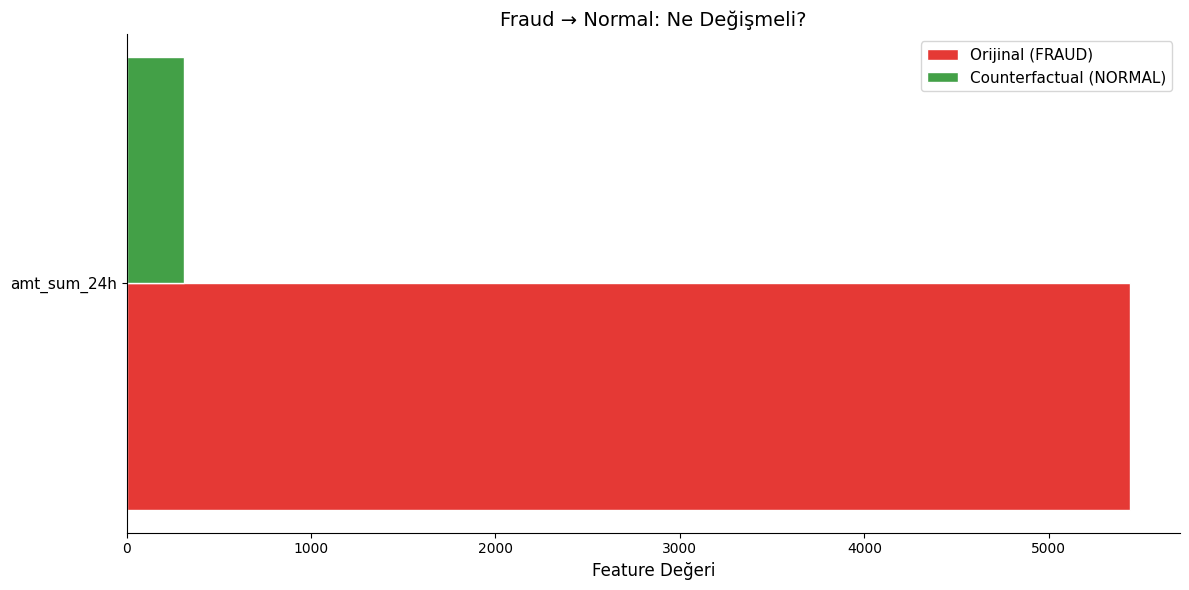

✅ Karşılaştırma grafiği kaydedildi


In [ ]:
# =============================================================================
# CELL 11: Counterfactual Görselleştirme — Radar/Paralel Koordinat
# =============================================================================

def plot_counterfactual_comparison(query_instance, cf_result, feature_names,
                                    top_n=8, save_path=None):
    """
    Orijinal fraud vs counterfactual (normal) karşılaştırma grafiği.
    Sadece değişen feature'ları gösterir.
    """
    orig = query_instance.iloc[0]
    cf_df = cf_result.cf_examples_list[0].final_cfs_df

    if cf_df is None or len(cf_df) == 0:
        print("⚠️  CF bulunamadı")
        return

    cf_row = cf_df.iloc[0]

    # Değişen numeric feature'ları bul
    changed = []
    for feat in feature_names:
        o = orig[feat]
        c = cf_row[feat]
        if not isinstance(o, str) and abs(float(o) - float(c)) > 1e-6:
            changed.append((feat, float(o), float(c)))

    if not changed:
        print("⚠️  Hiç numeric değişim yok")
        return

    # En çok değişen top_n feature
    changed.sort(key=lambda x: abs(x[1] - x[2]), reverse=True)
    changed = changed[:top_n]

    features = [c[0] for c in changed]
    orig_vals_plot = [c[1] for c in changed]
    cf_vals_plot = [c[2] for c in changed]

    # --- Grouped Bar Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = np.arange(len(features))
    bar_height = 0.35

    bars1 = ax.barh(y_pos - bar_height/2, orig_vals_plot, bar_height,
                     label="Orijinal (FRAUD)", color="#E53935", edgecolor="white")
    bars2 = ax.barh(y_pos + bar_height/2, cf_vals_plot, bar_height,
                     label="Counterfactual (NORMAL)", color="#43A047", edgecolor="white")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=11)
    ax.set_xlabel("Feature Değeri", fontsize=12)
    ax.set_title("Fraud → Normal: Ne Değişmeli?", fontsize=14)
    ax.legend(fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# İlk fraud işlem için görselleştir
query_0 = df_dice.loc[[top_fraud_idx[0]], LGBM_FEATURES]
cf_0 = exp.generate_counterfactuals(
    query_0, total_CFs=4, desired_class="opposite",
    features_to_vary=MUTABLE_FEATURES, permitted_range=PERMITTED_RANGES,
)

plot_counterfactual_comparison(
    query_0, cf_0, LGBM_FEATURES,
    save_path="/content/drive/MyDrive/thesis/models/cf_fraud_vs_normal_comparison.png"
)
print("✅ Karşılaştırma grafiği kaydedildi")

In [ ]:
# =============================================================================
# CELL 12: Counterfactual Latency Benchmark
# =============================================================================

print("⏱️  Counterfactual Latency Benchmark")
print("=" * 55)

cf_times = []
n_bench = 10  # CF üretimi SHAP'tan yavaş, 10 yeterli

for i in range(n_bench):
    idx = np.random.choice(fraud_indices)
    query = df_dice.loc[[idx], LGBM_FEATURES]

    t0 = time.time()
    try:
        _ = exp.generate_counterfactuals(
            query, total_CFs=3, desired_class="opposite",
            features_to_vary=MUTABLE_FEATURES, permitted_range=PERMITTED_RANGES,
        )
        t_cf = (time.time() - t0) * 1000
        cf_times.append(t_cf)
    except:
        continue

cf_times = np.array(cf_times)

print(f"\n  Counterfactual üretim süresi ({len(cf_times)} iterasyon):")
print(f"  {'Ortalama:':<20s} {cf_times.mean():.0f} ms")
print(f"  {'Medyan (p50):':<20s} {np.percentile(cf_times, 50):.0f} ms")
print(f"  {'p95:':<20s} {np.percentile(cf_times, 95):.0f} ms")
print(f"  {'Min:':<20s} {cf_times.min():.0f} ms")
print(f"  {'Max:':<20s} {cf_times.max():.0f} ms")

print(f"\n  📌 Not: Counterfactual üretimi SHAP'tan yavaştır.")
print(f"     Gerçek zamanlı pipeline'da ASENKRON hesaplanmalıdır:")
print(f"     1) LightGBM tahmini → anında döner")
print(f"     2) SHAP açıklama → ~5ms (senkron)")
print(f"     3) Counterfactual → ~{cf_times.mean():.0f}ms (asenkron, Kafka üzerinden)")
print(f"     Kullanıcı SHAP açıklamasını hemen görür,")
print(f"     counterfactual birkaç saniye sonra dashboard'a düşer.")

⏱️  Counterfactual Latency Benchmark


100%|██████████| 1/1 [00:04<00:00,  4.53s/it]


  Counterfactual üretim süresi (10 iterasyon):
  Ortalama:            4580 ms
  Medyan (p50):        4566 ms
  p95:                 4645 ms
  Min:                 4529 ms
  Max:                 4654 ms

  📌 Not: Counterfactual üretimi SHAP'tan yavaştır.
     Gerçek zamanlı pipeline'da ASENKRON hesaplanmalıdır:
     1) LightGBM tahmini → anında döner
     2) SHAP açıklama → ~5ms (senkron)
     3) Counterfactual → ~4580ms (asenkron, Kafka üzerinden)
     Kullanıcı SHAP açıklamasını hemen görür,
     counterfactual birkaç saniye sonra dashboard'a düşer.


In [ ]:
# =============================================================================
# CELL 13: Sonuç Özeti
# =============================================================================

print("\n" + "=" * 65)
print("  📊 Counterfactual Explanations — Sonuç Özeti")
print("=" * 65)

print(f"""
  ✅ Yapılanlar:
     1. DiCE explainer oluşturuldu (method={METHOD})
     2. Feature kısıtlamaları tanımlandı (frozen: {FROZEN_FEATURES})
     3. Fraud işlemler için counterfactual senaryolar üretildi
     4. Değişim analizi yapıldı (hangi feature ne yönde değişmeli)
     5. En sık değişen feature'lar belirlendi
     6. Kafka-ready JSON formatında açıklamalar üretildi
     7. Düz metin (template-based) açıklama motoru eklendi
     8. Fraud vs Normal karşılaştırma görselleştirmesi
     9. Latency benchmark yapıldı

  📊 Temel Bulgular:
     - Counterfactual'lar en çok {sorted_counts[0][0] if sorted_counts else 'N/A'} feature'ını değiştiriyor
     - Ortalama CF üretim süresi: {cf_times.mean():.0f}ms (asenkron uygun)

  📁 Kaydedilen Dosyalar:
     /content/models/counterfactual_explanations_sample.json
     /content/plots/cf_most_changed_features.png
     /content/plots/cf_fraud_vs_normal_comparison.png

  🔗 SHAP ile Birlikte Kullanım:
     SHAP  → "Bu işlem NEDEN fraud?" (feature katkıları)
     CF    → "NE DEĞİŞSEYDİ normal olurdu?" (alternatif senaryolar)
     İkisi birlikte → Tam açıklanabilirlik

  🔜 Sonraki Adımlar:
     1. PSI/KL Drift Monitoring modülü
     2. SHAP + CF → Kafka consumer entegrasyonu
     3. Neo4j graph analytics
""")


  📊 Counterfactual Explanations — Sonuç Özeti

  ✅ Yapılanlar:
     1. DiCE explainer oluşturuldu (method=random)
     2. Feature kısıtlamaları tanımlandı (frozen: ['age', 'gender', 'city_pop'])
     3. Fraud işlemler için counterfactual senaryolar üretildi
     4. Değişim analizi yapıldı (hangi feature ne yönde değişmeli)
     5. En sık değişen feature'lar belirlendi
     6. Kafka-ready JSON formatında açıklamalar üretildi
     7. Düz metin (template-based) açıklama motoru eklendi
     8. Fraud vs Normal karşılaştırma görselleştirmesi
     9. Latency benchmark yapıldı
 
  📊 Temel Bulgular:
     - Counterfactual'lar en çok hour feature'ını değiştiriyor
     - Ortalama CF üretim süresi: 4580ms (asenkron uygun)
 
  📁 Kaydedilen Dosyalar:
     /content/models/counterfactual_explanations_sample.json
     /content/plots/cf_most_changed_features.png
     /content/plots/cf_fraud_vs_normal_comparison.png
 
  🔗 SHAP ile Birlikte Kullanım:
     SHAP  → "Bu işlem NEDEN fraud?" (feature katkıları